In [7]:
import warnings
import numpy as np
import jax
import jax.numpy as jnp
import neural_tangents as nt
from neural_tangents import stax
from scipy.special import sph_harm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
import matplotlib.cm as cm
from jax import random

warnings.filterwarnings(
    "ignore",
    message="`scipy.special.sph_harm` is deprecated*",  # match SciPy's exact message
    category=DeprecationWarning
)

Data generation for this multitask setup

In [20]:
def generate_single_circle(normal, pts, m, phase=0.0):
    
    # Normalize just in case
    n = normal / np.linalg.norm(normal)
    v1 = np.array([1., 0., 0.]) if abs(n[0]) < 0.9 else np.array([0., 1., 0.])
    v1 = v1 - n * np.dot(n, v1)
    v1 /= np.linalg.norm(v1)
    v2 = np.cross(n, v1)

    # Apply phase shift directly to phi
    phi = np.linspace(0, 2*np.pi, pts, endpoint=False) + phase
    phi = phi % (2*np.pi)

    # Geometry on the sphere
    X = np.outer(np.cos(phi), v1) + np.outer(np.sin(phi), v2)

    # Circular harmonic ground truth
    y = np.sin(m * phi)

    return X, y

def generate_normals(K):

    # Fibonacci sphere sampling to get normals
    idx = np.arange(0, K, dtype=float) + 0.5
    phi = np.arccos(1 - 2 * idx / K)
    theta = np.pi * (1 + 5**0.5) * idx
    
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)
    
    return np.vstack([x, y, z]).T

def generate_multi_great_circle_tasks(
    K_tasks=2,
    pts_per_circle=512,
    m=4,
    phase=0.0,
    random_phase=False
):
    normals = generate_normals(K_tasks)

    X_list, y_list, slices = [], [], []
    start = 0

    for j, n in enumerate(normals):
        if random_phase:
            phase_j = np.random.rand() * 2*np.pi
        else:
            phase_j = phase

        X, y = generate_single_circle(n, pts_per_circle, m, phase=phase_j)

        X_list.append(X)
        y_list.append(y)
        slices.append(slice(start, start + pts_per_circle))
        start += pts_per_circle

    return (
        np.vstack(X_list),
        np.concatenate(y_list),
        slices,
        normals,
    )
    
def top_eig_power_iteration(K: jnp.ndarray,
                            n_iter: int = 50,
                            tol: float = 1e-6,
                            seed: int = 0):
    """
    Estimate largest eigenvalue of symmetric PSD K via power iteration.
    Returns: (lambda_max_est, v)
    """
    assert K.ndim == 2 and K.shape[0] == K.shape[1]
    n = K.shape[0]

    key = jax.random.PRNGKey(seed)
    v = jax.random.normal(key, (n,), dtype=K.dtype)
    v = v / jnp.linalg.norm(v)

    def body(state, _):
        v, lam_old = state
        w = K @ v
        v_new = w / jnp.linalg.norm(w)
        lam_new = jnp.vdot(v_new, K @ v_new).real  # Rayleigh quotient
        return (v_new, lam_new), lam_new

    # initialize lam_old = 0
    (v_fin, lam_fin), lams = jax.lax.scan(body, (v, jnp.array(0., K.dtype)), None, length=n_iter)

    # Optional: crude convergence check using last few Rayleigh quotients
    # (keep it simple; you can also stop early with a while_loop)
    return lam_fin, v_fin

def run_ntk_multi_great_circle(
    K_tasks=2,
    pts_per_circle=512,
    m=4,
    W_std=1.0,
    b_std=1.0,
    reg_scale=1e-5,
    trainable=("W", "b"),
    hidden_layers=1,
    width=None,
    seed=0,
):
    """
    NTK multitask on K great-circle tasks with fixed degree m.

    If width is None:
        use *analytic* (infinite-width) NTK via stax.kernel_fn.
    If width is an int:
        use *finite-width* empirical NTK for a network with `width` units
        per hidden layer.

    Returns per-task test MSEs + predictions + geometry.
    """

    X_train_np, y_train_np, task_slices_train, normals_train = generate_multi_great_circle_tasks(
        K_tasks=K_tasks,
        pts_per_circle=pts_per_circle,
        m=m,
    )

    # Use random phase because otherwise the test includes the training
    X_test_np, y_test_np, task_slices_test, normals_test = generate_multi_great_circle_tasks(
        K_tasks=K_tasks,
        pts_per_circle=2 * pts_per_circle,
        m=m,
        random_phase=True
    )

    X_train = jnp.array(X_train_np, dtype=jnp.float32)
    y_train = jnp.array(y_train_np, dtype=jnp.float32)
    X_test  = jnp.array(X_test_np,  dtype=jnp.float32)
    y_test  = jnp.array(y_test_np,  dtype=jnp.float32)

    N_train = X_train.shape[0]

    if width is None:

        # Do Infinite-width analytic NTK
        layers = []
        for _ in range(hidden_layers):
            # Width does not matter in the analytic NTK because neural tangents ignores it anyways
            layers.append(
                stax.Dense(
                    1,
                    W_std=W_std,
                    b_std=b_std,
                    parameterization="ntk",
                    trainable=trainable,
                )
            )
            layers.append(stax.Relu())

        # Final scalar output layer
        layers.append(
            stax.Dense(
                1,
                W_std=W_std,
                b_std=b_std,
                parameterization="ntk",
                trainable=trainable,
            )
        )

        _, _, kernel_fn = stax.serial(*layers)
        kernel_fn = nt.batch(kernel_fn, device_count=-1)

        # Get kernels
        K_train = jnp.array(kernel_fn(X_train, X_train, "ntk"))
        K_test_train = jnp.array(kernel_fn(X_test, X_train, "ntk"))

    else:

        # Do Finite-width empirical NTK
        layers = []
        for _ in range(hidden_layers):
            layers.append(
                stax.Dense(
                    width,
                    W_std=W_std,
                    b_std=b_std,
                    parameterization="ntk",
                    trainable=trainable,
                )
            )
            layers.append(stax.Relu())

        # Final scalar output layer
        layers.append(
            stax.Dense(
                1,
                W_std=W_std,
                b_std=b_std,
                parameterization="ntk",
                trainable=trainable,
            )
        )

        init_fn, apply_fn, _ = stax.serial(*layers)
        _, params = init_fn(random.PRNGKey(seed), X_train.shape)

        ntk_fn = nt.empirical_ntk_fn(
            f=apply_fn,
            trace_axes=(),
            vmap_axes=0,
            implementation=nt.NtkImplementation.STRUCTURED_DERIVATIVES,
        )

        # Since empirical_ntk_fn typically returns (N1, N2, 1, 1) for scalar outputs we squeeze it
        K_train = ntk_fn(X_train, X_train, params)
        K_test_train = ntk_fn(X_test, X_train, params)

        if K_train.ndim == 4:
            K_train = jnp.squeeze(K_train, axis=(-1, -2))
            K_test_train = jnp.squeeze(K_test_train, axis=(-1, -2))

    # eigvals = jnp.linalg.eigvalsh(K_train)
    # lam_max = float(np.max(eigvals))              # from eigvalsh(K)
    
    top_eig_power_iteration_jit = jax.jit(top_eig_power_iteration, static_argnames=("n_iter","tol","seed"))
    
    lam_max, v = top_eig_power_iteration_jit(K_train, n_iter=60, seed=0)
    
    s_trace = float(np.trace(K_train) / K_train.shape[0])

    K_tilde = K_train / s_trace

    eps_max = reg_scale
    eps_trace = eps_max * (lam_max / s_trace)

    K_reg = K_tilde + eps_trace * jnp.eye(K_tilde.shape[0], dtype=K_tilde.dtype)
    
    y_train_col = y_train.reshape(-1, 1)
    alpha = jnp.linalg.solve(K_reg, y_train_col)

    # Predict on test set and flatten
    y_pred_test = (K_test_train @ alpha).reshape(-1)

    # Save data
    task_results = []
    mse_test_per_task = []

    for sl in task_slices_test:
        yt = np.array(y_test_np[sl])
        yp = np.array(y_pred_test[sl])
        mse = float(np.mean((yt - yp) ** 2))

        Xt = np.array(X_test_np[sl])
        task_results.append(
            dict(
                y_true=yt,
                y_pred=yp,
                X=Xt,
            )
        )
        mse_test_per_task.append(mse)

    return dict(
        K_tasks=K_tasks,
        pts_per_circle=pts_per_circle,
        m=m,
        reg=eps_trace,
        eigvals=None,
        mse_per_task=mse_test_per_task,
        tasks=task_results,
        normals_train=np.array(normals_train),
        normals_test=np.array(normals_test),
        width=width,
    )

def run_single_circle_ntk_task(
    normal,
    pts_per_circle=512,
    m=4,
    W_std=1.0,
    b_std=1.0,
    reg_scale=1e-5,
    trainable=("W", "b"),
    hidden_layers=1,
    width=None,
    seed=0,
):
    """
    Single great-circle NTK regressxion for a given normal.

    If width is None:
        Use analytic (infinite-width) NTK via stax.kernel_fn.
    If width is an int:
        Use finite-width empirical NTK for a network with `width` units
        per hidden layer.
    """

    # Same as previous function
    X_train_np, y_train_np = generate_single_circle(normal, pts_per_circle, m)
    X_test_np,  y_test_np  = generate_single_circle(normal, pts_per_circle * 2, m=m, phase=np.random.rand()*2*np.pi)

    X_train = jnp.array(X_train_np, dtype=jnp.float32)
    y_train = jnp.array(y_train_np, dtype=jnp.float32)
    X_test  = jnp.array(X_test_np,  dtype=jnp.float32)
    y_test  = jnp.array(y_test_np,  dtype=jnp.float32)

    N_train = X_train.shape[0]

    if width is None:

        layers = []
        for _ in range(hidden_layers):

            layers.append(
                stax.Dense(
                    1,
                    W_std=W_std,
                    b_std=b_std,
                    parameterization="ntk",
                    trainable=trainable,
                )
            )
            layers.append(stax.Relu())

        layers.append(
            stax.Dense(
                1,
                W_std=W_std,
                b_std=b_std,
                parameterization="ntk",
                trainable=trainable,
            )
        )

        _, _, kernel_fn = stax.serial(*layers)
        kernel_fn = nt.batch(kernel_fn)

        K_train = kernel_fn(X_train, X_train, "ntk")
        K_test_train = kernel_fn(X_test, X_train, "ntk")

    else:

        layers = []
        for _ in range(hidden_layers):
            layers.append(
                stax.Dense(
                    width,
                    W_std=W_std,
                    b_std=b_std,
                    parameterization="ntk",
                    trainable=trainable,
                )
            )
            layers.append(stax.Relu())

        layers.append(
            stax.Dense(
                1,
                W_std=W_std,
                b_std=b_std,
                parameterization="ntk",
                trainable=trainable,
            )
        )

        init_fn, apply_fn, _ = stax.serial(*layers)
        _, params = init_fn(random.PRNGKey(seed), X_train.shape)

        ntk_fn = nt.empirical_ntk_fn(
            f=apply_fn,
            trace_axes=(),
            vmap_axes=0,
            implementation=nt.NtkImplementation.STRUCTURED_DERIVATIVES,
        )

        K_train = ntk_fn(X_train, X_train, params)
        K_test_train = ntk_fn(X_test, X_train, params)

        if K_train.ndim == 4:
            K_train = jnp.squeeze(K_train, axis=(-1, -2))
            K_test_train = jnp.squeeze(K_test_train, axis=(-1, -2))
    
    # eigvals = jnp.linalg.eigvalsh(K_train)
    # lam_max = float(np.max(eigvals))              # from eigvalsh(K)
    top_eig_power_iteration_jit = jax.jit(top_eig_power_iteration, static_argnames=("n_iter","tol","seed"))
    lam_max, v = top_eig_power_iteration_jit(K_train, n_iter=60, seed=0)
    s_trace = float(np.trace(K_train) / K_train.shape[0])

    K_tilde = K_train / s_trace

    eps_max = reg_scale
    eps_trace = eps_max * (lam_max / s_trace)

    K_reg = K_tilde + eps_trace * jnp.eye(K_tilde.shape[0], dtype=K_tilde.dtype)
    y_train_col = y_train.reshape(-1, 1)
    alpha = jnp.linalg.solve(K_reg, y_train_col)

    y_pred = (K_test_train @ alpha).reshape(-1)

    mse = float(jnp.mean((y_test - y_pred) ** 2))

    return dict(
        mse=mse,
        reg=eps_trace,
        eigvals=None,
        y_true=np.array(y_test_np),
        y_pred=np.array(y_pred),
        X_test=np.array(X_test_np),
        normal=np.array(normal),
        width=width,
    )

Let's define the visulization functions

In [23]:
def plot_great_circles_3d(X, y, task_slices, elev=25, azim=25, cmap="viridis"):

    """
    Plot training data of different-circle harmonics on the sphere
    """

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')

    # Plot circles (save the last scatter handle)
    sc = None
    for sl in task_slices:
        sc = ax.scatter(X[sl,0], X[sl,1], X[sl,2],
                        c=y[sl], cmap=cmap,
                        s=25, alpha=0.95)

    # Sphere grid
    u = np.linspace(0, 2*np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color='gray', alpha=0.15, linewidth=0.5)

    ax.set_title("Great-Circle Tasks on the Sphere")
    ax.view_init(elev=elev, azim=azim)
    ax.set_box_aspect((1,1,1))

    # Add colorbar (using last scatter)
    cbar = fig.colorbar(sc, ax=ax, shrink=0.7)
    cbar.set_label("y value")

    plt.show()


def plot_circle_harmonics(y, task_slices, m, cmap=cm.viridis):

    """
    Show all the harmonics, each just considering its own circle
    """

    plt.figure(figsize=(10,4))

    K = len(task_slices)
    colors = cmap(np.linspace(0, 1, K, endpoint=False))

    for i, sl in enumerate(task_slices):
        N = sl.stop - sl.start
        phi = np.linspace(0, 2*np.pi, N, endpoint=False)
        plt.plot(phi, y[sl], lw=2, label=f"Task {i+1}", color=colors[i])

    plt.xlabel("theta")
    plt.ylabel(f"sin({m}theta)")
    plt.title(f"Circular Harmonic (m = {m})")
    plt.grid(True, alpha=0.4)

    plt.legend(
        bbox_to_anchor=(1.02, 0.5),
        loc="center left",
        borderaxespad=0.,
        ncol=max(1, K // 10)
    )

    plt.tight_layout()
    plt.show()

def plot_multi_circle_avg_performance(results,
                                      single_task_results=None,
                                      single_task_label="Single-task (rotated circles)"):

    """
    Plot multi-task NTK performance (avg test MSE vs #tasks).
    Optionally overlay single-task experiment (each task trained independently).
    """

    plt.figure(figsize=(8,5))

    # Multi-task experiment
    Ks = [res['K_tasks'] for res in results]
    mean_mse = [jnp.mean(jnp.array(res['mse_per_task'])) for res in results]

    plt.semilogy(Ks, mean_mse, 'o-', lw=2, label="Multi-task NTK")
    print(Ks, mean_mse)

    # Baseline line
    plt.axhline(y=0.5, label="Const 0 pred", c="red", linestyle="--")

    # Optional overlay: Single-task performance across geometries
    if single_task_results is not None:
        mse_vals = [r['mse'] for r in single_task_results]
        task_ids = np.arange(len(mse_vals))
        plt.semilogy(task_ids+1, mse_vals, 'o-', lw=1.5, c="black",
                     label=single_task_label)

    plt.xlabel("Number of Tasks")
    plt.ylabel("Avg Test MSE")
    plt.title("NTK Multi-Task Capacity on the sphere")
    plt.grid(True, which='both')

    plt.tight_layout()
    plt.legend()
    plt.show()

def plot_multi_circle_worst_performance(results,
                                        single_task_results=None,
                                        single_task_label="Single-task (rotated circles)"):

    """
    Plot multi-task NTK worst-case performance (max test MSE per task vs #tasks).
    Optionally overlay single-task experiment (each circle trained independently).
    """

    plt.figure(figsize=(8,5))

    # Multi-task experiment
    Ks = [res['K_tasks'] for res in results]
    worst_mse = [jnp.max(jnp.array(res['mse_per_task'])) for res in results]

    plt.semilogy(Ks, worst_mse, 'o-', lw=2, label="Multi-task NTK (worst per task)")

    # Baseline
    plt.axhline(y=0.5, label="Const 0 pred", c="red", linestyle="--")

    # Optional overlay: Single-task performance across geometries
    if single_task_results is not None:
        mse_vals = [r['mse'] for r in single_task_results]
        task_ids = np.arange(len(mse_vals))
        plt.semilogy(task_ids+1, mse_vals, 'o-', lw=1.5, c="black",
                     label=single_task_label)

    plt.xlabel("Number of Tasks")
    plt.ylabel("Worst Test MSE")
    plt.title("Worst-Case NTK Multi-Task Capacity on the sphere")
    plt.grid(True, which='both')

    plt.tight_layout()
    plt.legend()
    plt.show()


def plot_per_task_mse(results, show_legend=True, cmap="viridis"):
    
    """
    On a series of multitask kernel regressions for different number of tasks,
    plot a curve for each K_tasks setup, where the points are the single task
    mse for the multitask kernel (meaning the performance of the multitask kernel
    on the points of each task singularly). 
    """
    
    plt.figure(figsize=(8,5))

    cm = plt.colormaps.get_cmap(cmap)
    K_results = len(results)

    for i, res in enumerate(results):
        K = res['K_tasks']
        mses = res['mse_per_task']

        # Sample evenly from colormap
        color = cm(i / max(1, K_results - 1))
        
        plt.plot(range(1, K+1), mses, 'o-', label=f"K={K}", color=color)

    plt.axhline(y=0.5, label="Const 0 pred", c="red", linestyle="--")

    plt.xlabel("Task index")
    plt.ylabel("Test MSE per task")
    plt.yscale("log")
    plt.title("Task Interference Structure")
    plt.grid(True, alpha=0.4)
    if show_legend:
        ncol=max(1,len(results)//6)
        plt.legend(ncol=ncol)
    plt.tight_layout()
    plt.show()

def plot_sorted_task_mse(results, show_legend=True, cmap="viridis"):

    """
    On a series of multitask kernel regressions for different number of tasks,
    plot a curve for each K_tasks setup, where the points are the single task
    mse for the multitask kernel (meaning the performance of the multitask kernel
    on the points of each task singularly). The points are sorted by mse.
    """

    plt.figure(figsize=(8,5))

    cm = plt.colormaps.get_cmap(cmap)
    K_results = len(results)

    for i, res in enumerate(results):
        K = res['K_tasks']
        sorted_mses = sorted(res["mse_per_task"])

        # Sample evenly from colormap
        color = cm(i / max(1, K_results - 1))

        plt.semilogy(range(1, K+1), sorted_mses, 'o-', label=f"K={K}", color=color)

    plt.axhline(y=0.5, label="Const 0 pred", c="red", linestyle="--")

    plt.xlabel("Tasks sorted by MSE")
    plt.ylabel("Test MSE")
    plt.title("Multi-Task Capacity (sorted)")
    plt.grid(True, alpha=0.4)

    if show_legend:
        ncol = max(1, K_results // 6)
        plt.legend(ncol=ncol)

    plt.tight_layout()
    plt.show()
    
def plot_true_vs_pred(idx, normals, configs, results, cmap="viridis"):

    # Retrieve task info
    normal = normals[idx]
    pts = configs[idx]['pts_per_circle'] * 2
    m = configs[idx]['m']
    res = results[idx]

    # Generate geometry consistent with results
    X = generate_single_circle(normal, pts, m)[0]

    y_true = np.array(res["y_true"], dtype=float).ravel()
    y_pred = np.array(res["y_pred"], dtype=float).ravel()

    # Shared color range
    vmin = min(y_true.min(), y_pred.min())
    vmax = max(y_true.max(), y_pred.max())

    fig = plt.figure(figsize=(12, 5), constrained_layout=True)
    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122, projection='3d')

    # True values
    sc1 = ax1.scatter(*X.T,
                      c=y_true, cmap=cmap, s=22,
                      vmin=vmin, vmax=vmax)
    ax1.set_title(f"True — Circle {idx}")
    ax1.set_box_aspect([1,1,1])
    ax1.view_init(20, 45)

    # Pred values
    sc2 = ax2.scatter(*X.T,
                      c=y_pred, cmap=cmap, s=22,
                      vmin=vmin, vmax=vmax)
    ax2.set_title(f"Predicted — Circle {idx}") 
    ax2.set_box_aspect([1,1,1])
    ax2.view_init(20, 45)

    # Shared colorbar — properly spaced
    cbar = fig.colorbar(sc2, ax=[ax1, ax2],
                        location="right",
                        shrink=0.85,
                        pad=0.1)
    cbar.set_label("sin(m theta)")

    plt.suptitle(f"Orientation {idx} — normal={normal.round(3)}")
    plt.show()

Show an example of the tasks

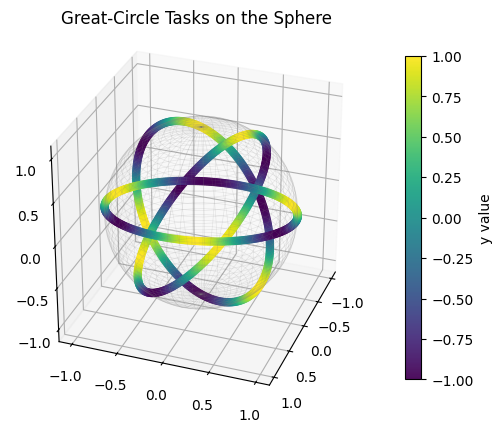

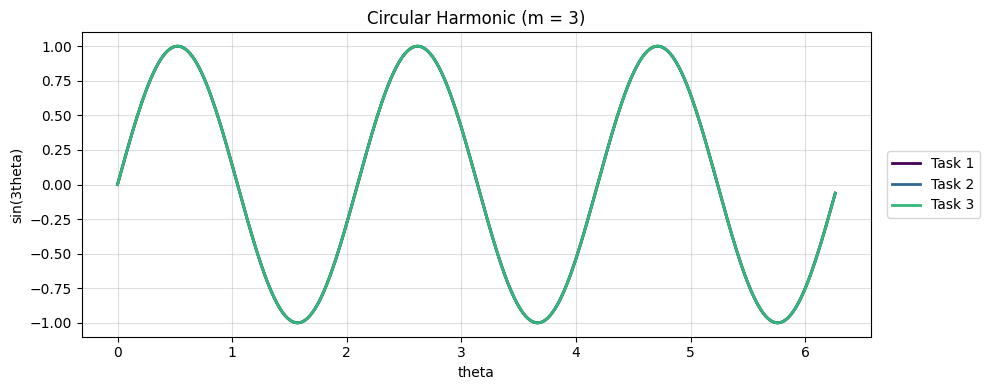

In [4]:
K = 3 # Number of tasks 
m = 3  # Degree of each harmonic

X_train, y_train, slices, normals = generate_multi_great_circle_tasks(
    K_tasks=K, pts_per_circle=300, m=m
)

plot_great_circles_3d(X_train, y_train, slices, elev=30, azim=20)
plot_circle_harmonics(y_train, slices, m)

In [5]:
def plot_great_circles_3d_2x2(Ks=(1, 2, 10, 30),
                             pts_per_circle=300,
                             m=3,
                             elev=30,
                             azim=20,
                             cmap="viridis"):

    fig = plt.figure(figsize=(9, 8))

    # Grid for plots + colorbar column
    gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.05],
                          wspace=0.05, hspace=0.15)

    # --- Handle scalar vs per-panel views ---
    n_panels = len(Ks)

    if np.isscalar(elev):
        elevs = [elev] * n_panels
    else:
        assert len(elev) == n_panels, "elev must match number of Ks"
        elevs = elev

    if np.isscalar(azim):
        azims = [azim] * n_panels
    else:
        assert len(azim) == n_panels, "azim must match number of Ks"
        azims = azim

    axes = []
    for i, (K, el, az) in enumerate(zip(Ks, elevs, azims)):
        ax = fig.add_subplot(gs[i // 2, i % 2], projection="3d")
        axes.append(ax)

        X, y, slices, _ = generate_multi_great_circle_tasks(
            K_tasks=K,
            pts_per_circle=pts_per_circle,
            m=m
        )

        sc = None
        for sl in slices:
            sc = ax.scatter(
                X[sl, 0], X[sl, 1], X[sl, 2],
                c=y[sl], cmap=cmap,
                s=18, alpha=0.95
            )

        # Sphere wireframe
        u = np.linspace(0, 2*np.pi, 40)
        v = np.linspace(0, np.pi, 40)
        xs = np.outer(np.cos(u), np.sin(v))
        ys = np.outer(np.sin(u), np.sin(v))
        zs = np.outer(np.ones_like(u), np.cos(v))
        ax.plot_wireframe(xs, ys, zs,
                          color="gray", alpha=0.15, linewidth=0.5)

        ax.set_title(f"K = {K}", fontsize=12)
        ax.view_init(elev=el, azim=az)
        ax.set_box_aspect((1, 1, 1))
        ax.set_axis_off()

    # Dedicated colorbar axis
    cax = fig.add_subplot(gs[:, 2])
    cbar = fig.colorbar(sc, cax=cax)
    cbar.set_label(r"$\sin(3\theta)$")

    plt.suptitle(f"Great-Circle Harmonic Tasks on $S^2$)",
                 fontsize=14)
    plt.show()


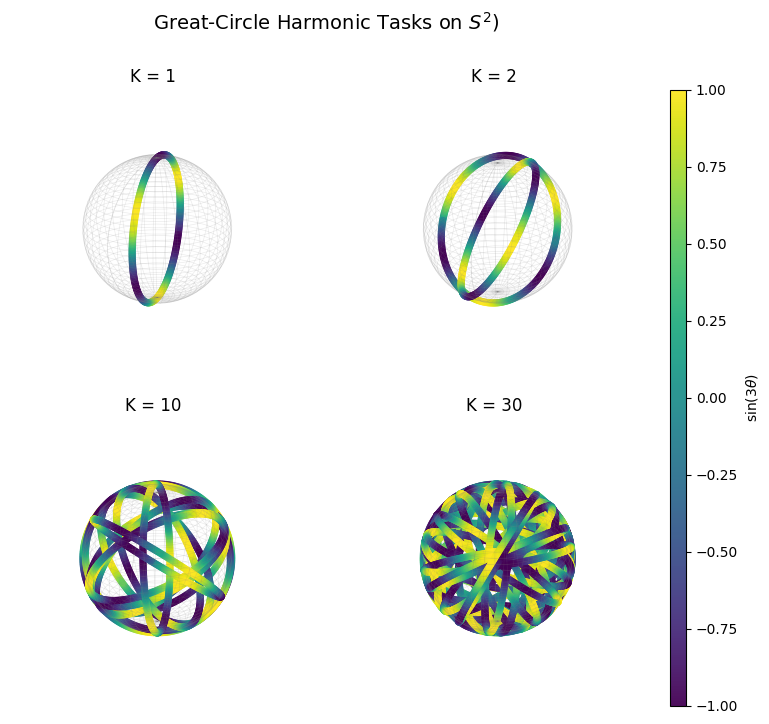

In [6]:
plot_great_circles_3d_2x2(
    elev=[20, 30, 30, 30],
    azim=[40, 20, 20, 20]
)

Use harmonic of degree 4 because it's the first non-trivial one that can be learned in all cases (full ntk no bias, full ntk with bias, bias only ntk). We first have to check that, however we orient the great circle, the ntk can learn the 4th degree harmonic on it.

In [16]:
num_tasks = 90
m = 4
pts_per_circle = 256
reg_scale = 1.35E-3

# Uniform, unique normals
normals = generate_normals(num_tasks)

configs = []
for j in range(num_tasks):
    configs.append(dict(
        normal=normals[j],
        pts_per_circle=pts_per_circle,
        m=m,
        reg_scale=reg_scale
    ))

results_single = []
for cfg in tqdm(configs, desc="Running single-task sin(4 theta) NTK regressions"):
    results_single.append(run_single_circle_ntk_task(**cfg))

Running single-task sin(4 theta) NTK regressions: 100%|██████████| 90/90 [00:17<00:00,  5.07it/s]


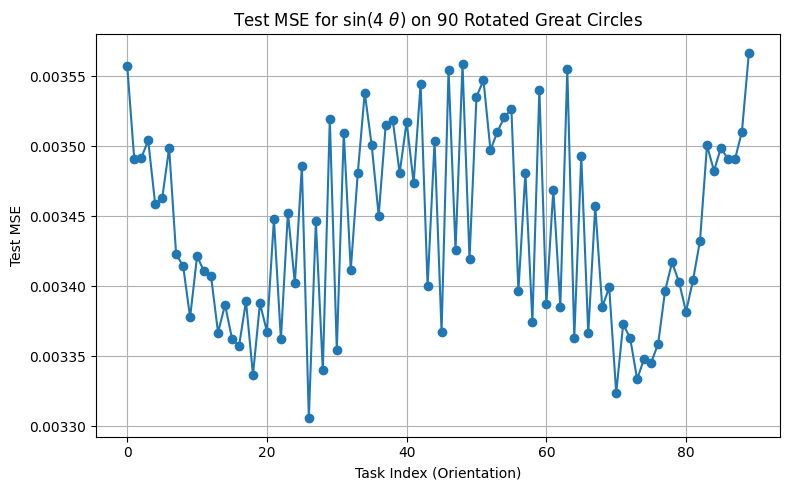

In [17]:
mse_vals = [r["mse"] for r in results_single]

plt.figure(figsize=(8,5))
plt.plot(range(num_tasks), mse_vals, marker='o')
plt.title(fr"Test MSE for sin(4 $\theta$) on {len(results_single)} Rotated Great Circles")
plt.xlabel("Task Index (Orientation)")
plt.ylabel("Test MSE")
plt.grid(True)
plt.tight_layout()
plt.show()

Make sure that the results are correct by plotting

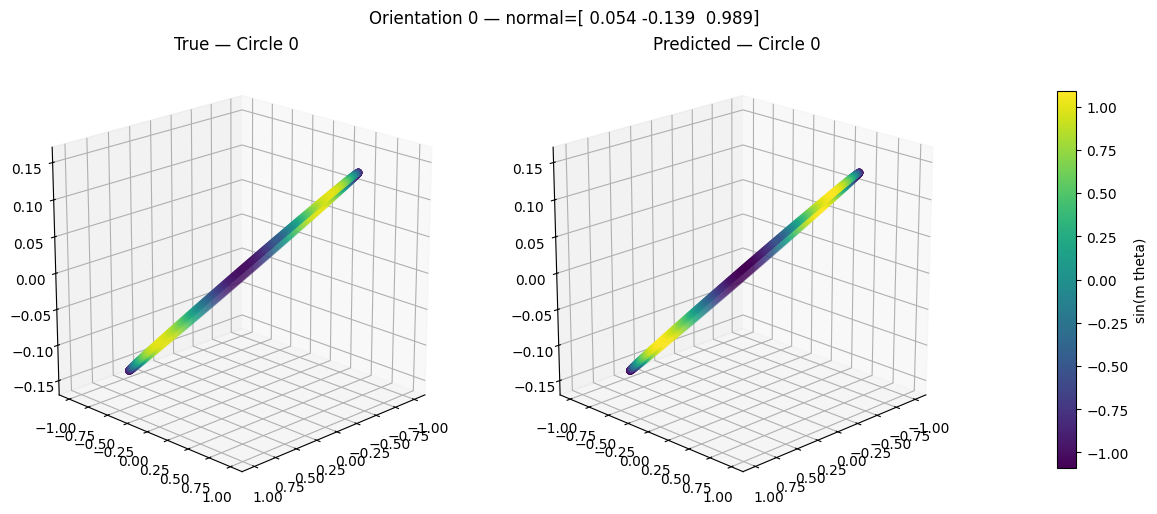

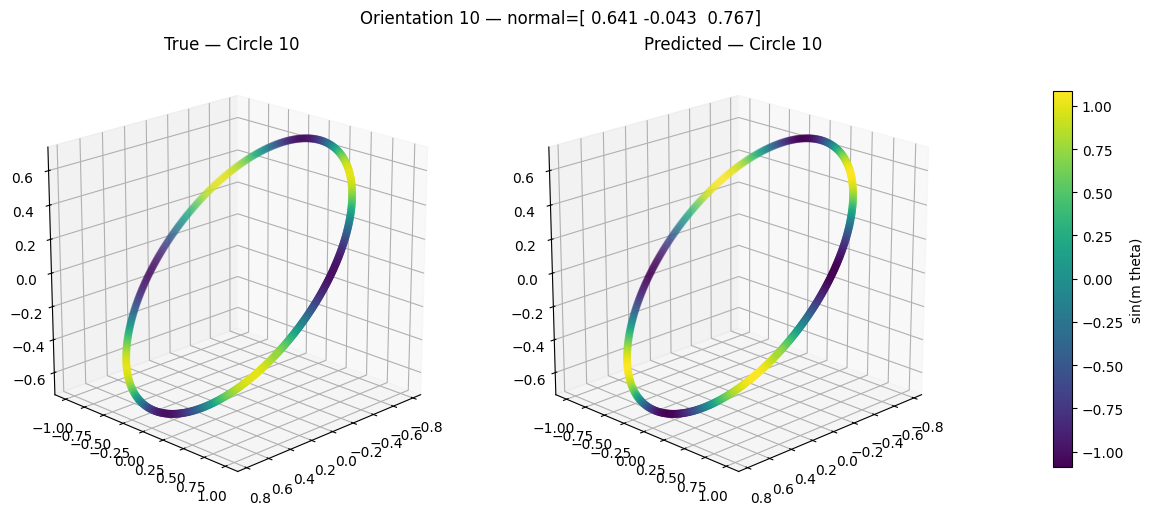

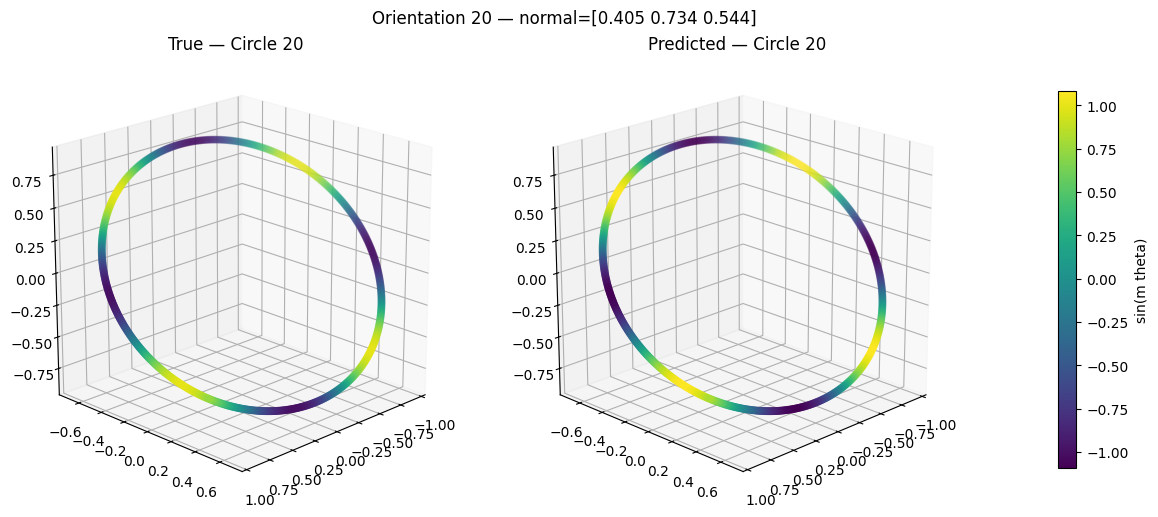

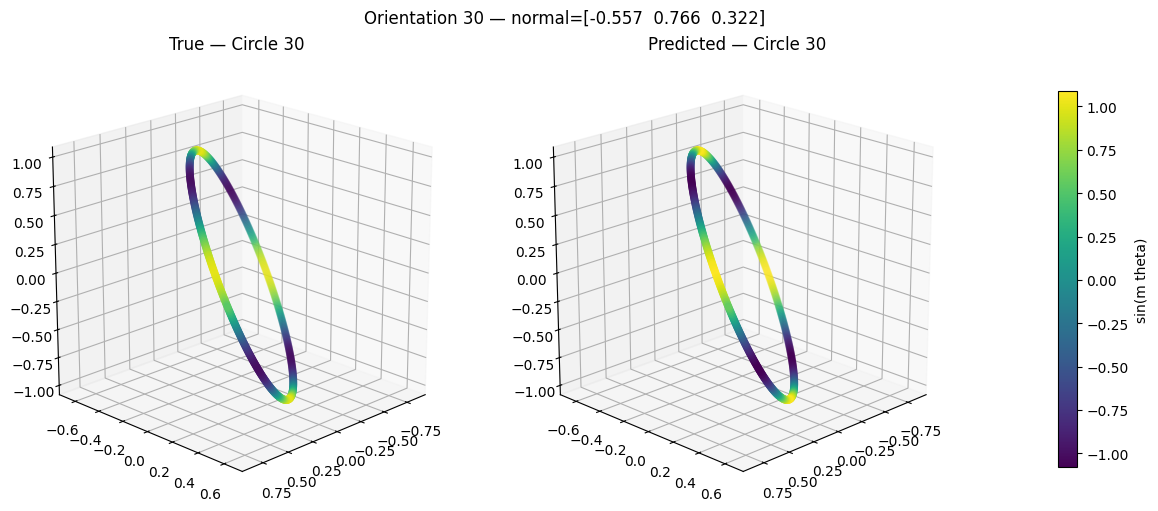

In [18]:
example_ids = [0, 10, 20, 30]
for idx in example_ids:
    plot_true_vs_pred(idx, normals, configs, results_single)

Now we can see what happens if we need to learn multiple at the same time.

In [37]:
configs = []
results_multi = []
m = 4

for K in [1,2,3,4,5,10,15,20,25,30,35,40,45,50,55,60,65,70]:
    configs.append(dict(K_tasks=K, pts_per_circle=256, m=m, reg_scale=1.35E-3))

for cfg in tqdm(configs):
    results_multi.append(run_ntk_multi_great_circle(**cfg))

100%|██████████| 18/18 [00:07<00:00,  2.47it/s]


[1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70] [Array(0.00352016, dtype=float32), Array(0.15596446, dtype=float32), Array(0.18902203, dtype=float32), Array(0.16109216, dtype=float32), Array(0.3245506, dtype=float32), Array(0.4217735, dtype=float32), Array(0.47365648, dtype=float32), Array(0.47887966, dtype=float32), Array(0.47800502, dtype=float32), Array(0.48863307, dtype=float32), Array(0.49191338, dtype=float32), Array(0.4930577, dtype=float32), Array(0.4928445, dtype=float32), Array(0.495361, dtype=float32), Array(0.4957912, dtype=float32), Array(0.49587137, dtype=float32), Array(0.4972875, dtype=float32), Array(0.49757734, dtype=float32)]


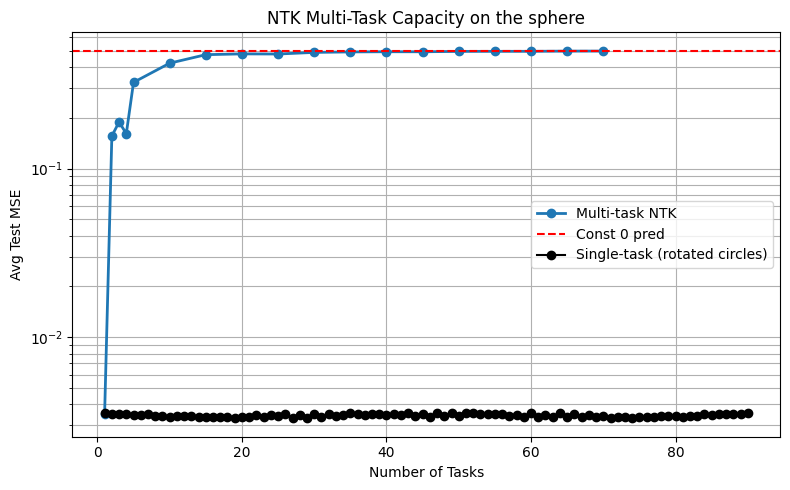

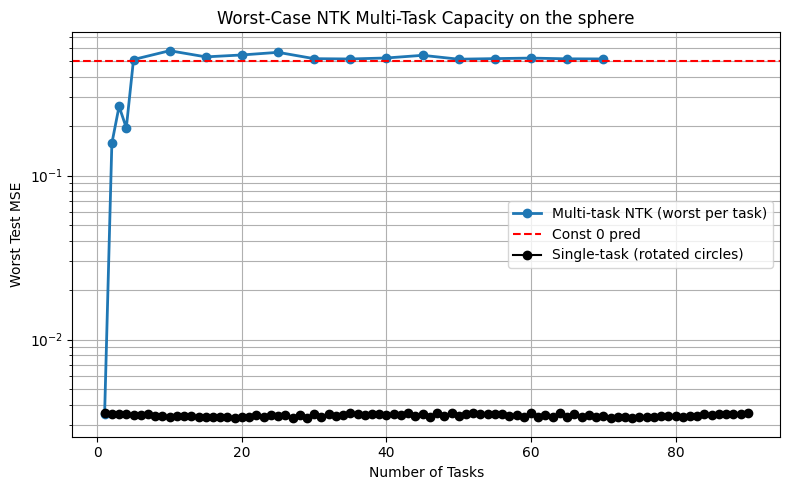

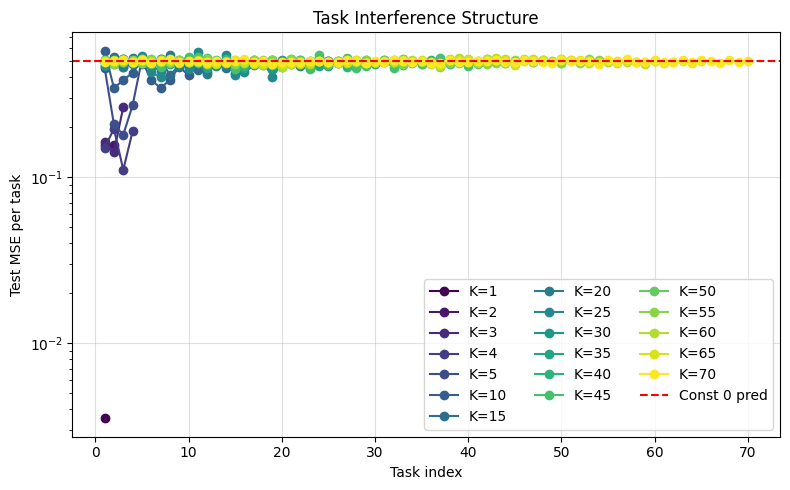

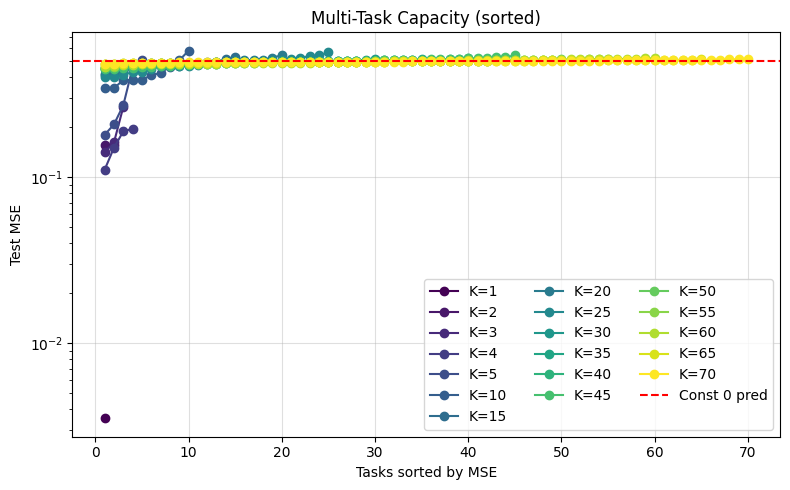

In [38]:
plot_multi_circle_avg_performance(results_multi,
                                  single_task_results=results_single)
plot_multi_circle_worst_performance(results_multi,
                                    single_task_results=results_single)
plot_per_task_mse(results_multi)
plot_sorted_task_mse(results_multi)

/tmp/ipykernel_1844703/1418790093.py:166: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


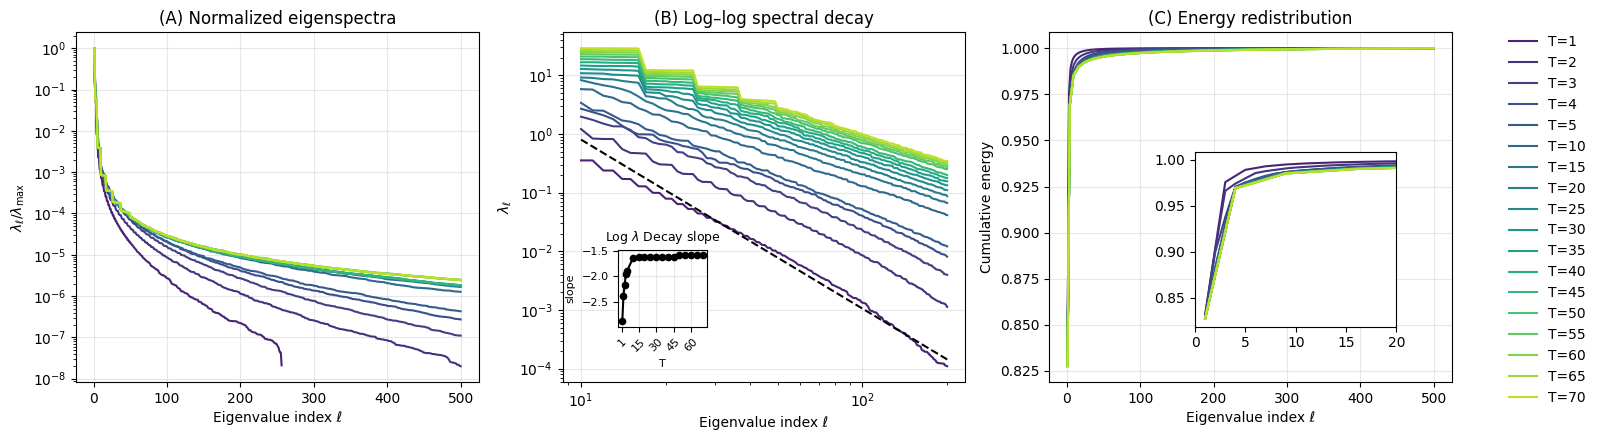

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def plot_spectral_diagnostics(
    eigvals_by_T: dict[int, np.ndarray],
    L_max: int | None = None,
    fit_range: tuple[int, int] = (5, 200),
    cmap: str = "viridis",
):
    """
    Plots:
      (A) normalized eigenvalue spectra
      (B) log-log decay comparison
      (C) cumulative spectral energy

    Args:
      eigvals_by_T: dict[T -> eigenvalues]
      L_max: truncate spectrum to first L_max modes (largest eigenvalues)
      fit_range: (ell_min, ell_max) for slope diagnostics (visual only)
      cmap: matplotlib colormap
    """

    Ts = sorted(eigvals_by_T.keys())
    nT = len(Ts)
    colors = plt.get_cmap(cmap)(np.linspace(0.1, 0.9, nT))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # --------------------------------------------------
    # (A) Normalized spectra: lambda_l / lambda_max
    # --------------------------------------------------
    ax = axes[0]
    for T, c in zip(Ts, colors):
        lam = np.asarray(eigvals_by_T[T], dtype=float)

        # sort descending
        lam = np.sort(lam)[::-1]
        if L_max is not None:
            lam = lam[:L_max]

        lam_norm = lam / np.max(lam)
        ell = np.arange(1, len(lam_norm) + 1)

        ax.plot(ell, lam_norm, color=c, label=f"T={T}")

    ax.set_yscale("log")
    ax.set_xlabel("Eigenvalue index ℓ")
    ax.set_ylabel(r"$\lambda_\ell / \lambda_{\max}$")
    ax.set_title("(A) Normalized eigenspectra")
    ax.grid(True, alpha=0.3)

    # --------------------------------------------------
    # (B) Log–log decay comparison
    # --------------------------------------------------
    ax = axes[1]
    slopes = []
    for T, c in zip(Ts, colors):
        lam = np.asarray(eigvals_by_T[T], dtype=float)
        lam = np.sort(lam)[::-1]
        if L_max is not None:
            lam = lam[:L_max]

        ell = np.arange(1, len(lam) + 1)

        mask = (ell >= fit_range[0]) & (ell <= fit_range[1]) & (lam > 0)
        ax.plot(ell[mask], lam[mask], color=c, label=f"T={T}")
        #estimate log-log slope
        log_ell = np.log(ell[mask])
        log_lam = np.log(lam[mask])
        slope, intercept = np.polyfit(log_ell, log_lam, 1)
        slopes.append(slope)
        #if plotting first T, have example black log-log line
        if T == Ts[0]:
            ell_line = np.array(fit_range)
            lam_line = np.exp(intercept) * ell_line ** slope
            ax.plot(
                ell_line,
                lam_line,
                color="black",
                linestyle="--",
                linewidth=1.5,
                label=f"slope={slope:.2f}",
            )
    
    ax_in = inset_axes(
            ax,
            width="22%",     # fraction of parent axis
            height="22%",
            loc="lower left",
            borderpad=4.
        )
    T_arr = np.asarray(Ts)
    ax_in.plot(
                T_arr,
                slopes,
                marker="o",
                linestyle="-",
                linewidth=1.5,
                markersize=4.5,
                color="k",
            )
    ax_in.set_title(r"Log $\lambda$ Decay slope", fontsize=9)
    ax_in.set_xlabel("T", fontsize=8)
    ax_in.set_ylabel("slope", fontsize=8)

    # ax_in.tick_params(axis="both", which="major", labelsize=8)
    #set x tick labels to every 5 T
    tick_labels = np.array([1,15,30,45,60])
    ax_in.set_xticks(tick_labels)
    #rotate x tick labels
    plt.setp(ax_in.get_xticklabels(), rotation=45, ha="center", fontsize=8)
    plt.setp(ax_in.get_yticklabels(), fontsize=8)

    ax_in.grid(True, alpha=0.3)

    # Optional: compress y-range to emphasize differences
    ax_in.set_ylim(
        np.min(slopes) - 0.1,
        np.max(slopes) + 0.1
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Eigenvalue index ℓ")
    ax.set_ylabel(r"$\lambda_\ell$")
    ax.set_title("(B) Log–log spectral decay")
    ax.grid(True, alpha=0.3)

    # --------------------------------------------------
    # (C) Cumulative spectral energy
    # --------------------------------------------------
    ax = axes[2]
    ax_in = inset_axes(
            ax,
            width="50%",     # fraction of parent axis
            height="50%",
            loc="lower right",
            borderpad=4.
        )
    
    for T, c in zip(Ts, colors):
        lam = np.asarray(eigvals_by_T[T], dtype=float)
        lam = np.sort(lam)[::-1]
        if L_max is not None:
            lam = lam[:L_max]

        cum_energy = np.cumsum(lam) / np.sum(lam)
        ell = np.arange(1, len(cum_energy) + 1)

        ax.plot(ell, cum_energy, color=c, label=f"T={T}")
        ax_in.plot(ell, cum_energy, color=c)
    ax_in.set_xlim(0, 20)
    ax.set_xlabel("Eigenvalue index ℓ")
    ax.set_ylabel("Cumulative energy")
    # ax.set_ylim(0, 1.02)
    ax.set_title("(C) Energy redistribution")
    ax.grid(True, alpha=0.3)

    # --------------------------------------------------
    # Legend
    # --------------------------------------------------
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center right", frameon=False)
    plt.tight_layout(rect=[0, 0, 0.92, 1])
    plt.show()


#pack eigenvalues into dict with key as T
eig_dict = {}
for res in results_multi:
    T = res['K_tasks']
    eig_dict[T] = res['eigvals']
    
    
plot_spectral_diagnostics(
    eigvals_by_T=eig_dict,
    L_max=500,          # optional
    fit_range=(10, 200)
)

Get a zoom into the first K values to appreciate better what happens.

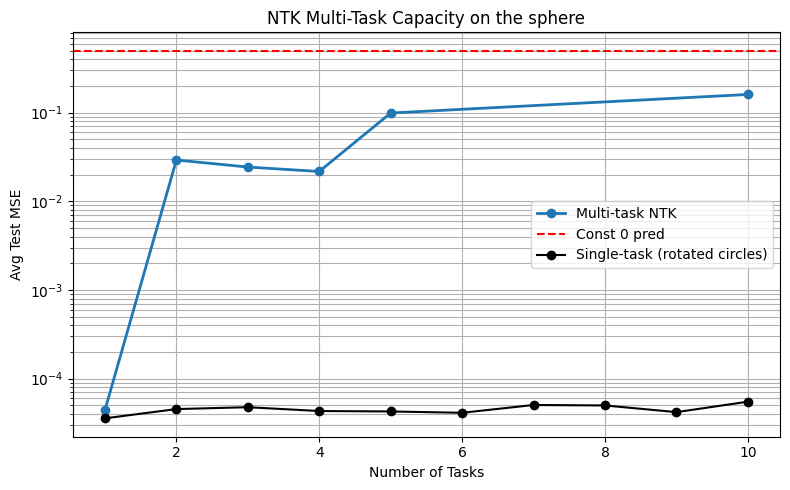

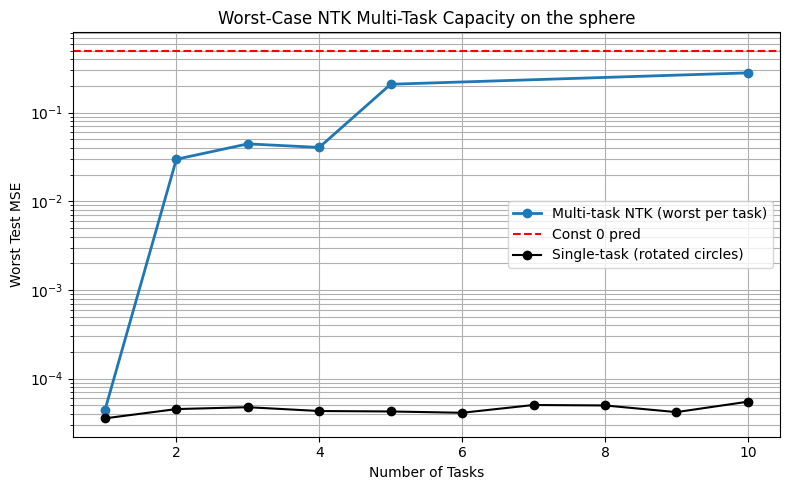

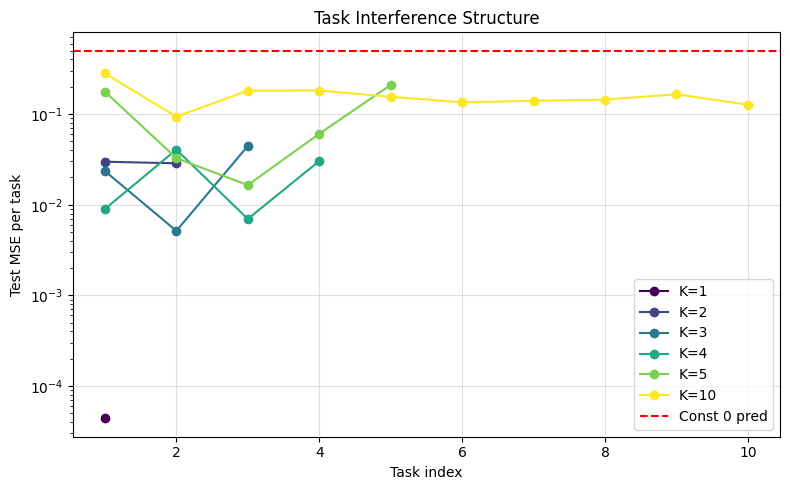

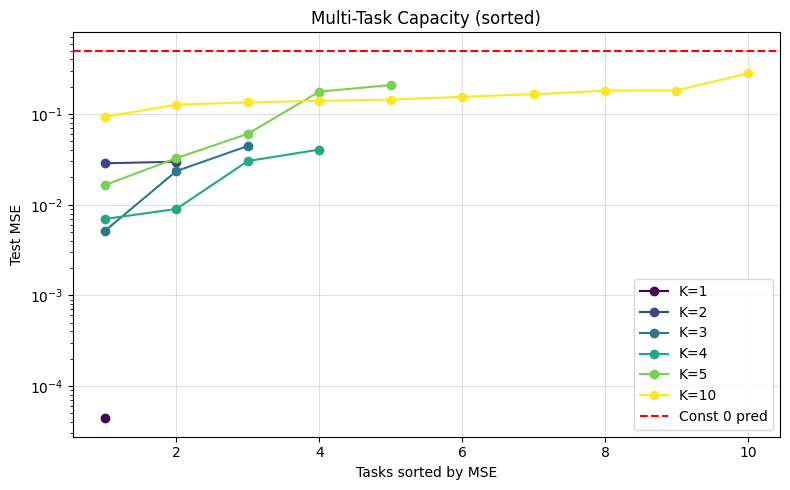

In [12]:
plot_multi_circle_avg_performance(results_multi[:6],
                                  single_task_results=results_single[:10])
plot_multi_circle_worst_performance(results_multi[:6],
                                    single_task_results=results_single[:10])
plot_per_task_mse(results_multi[:6])
plot_sorted_task_mse(results_multi[:6])

I believe the strange downward spike at l=4 happens because having 4 sin(4 theta) tasks on 4 euqidistant great circles induces some kind of symmetry that makes the total task easier on the spherical harmonics. Let's see what happens if we change the circle harmonic.

In [21]:
num_tasks = 90
m = 3
pts_per_circle = 512
reg_scale = 1e-5

# Uniform, unique normals
normals = generate_normals(num_tasks)

configs = []
for j in range(num_tasks):
    configs.append(dict(
        normal=normals[j],
        pts_per_circle=pts_per_circle,
        m=m,
        reg_scale=reg_scale
    ))

results_single = []
for cfg in tqdm(configs, desc="Running single-task sin(4 theta) NTK regressions"):
    results_single.append(run_single_circle_ntk_task(**cfg))

Running single-task sin(4 theta) NTK regressions: 100%|██████████| 90/90 [00:18<00:00,  4.81it/s]


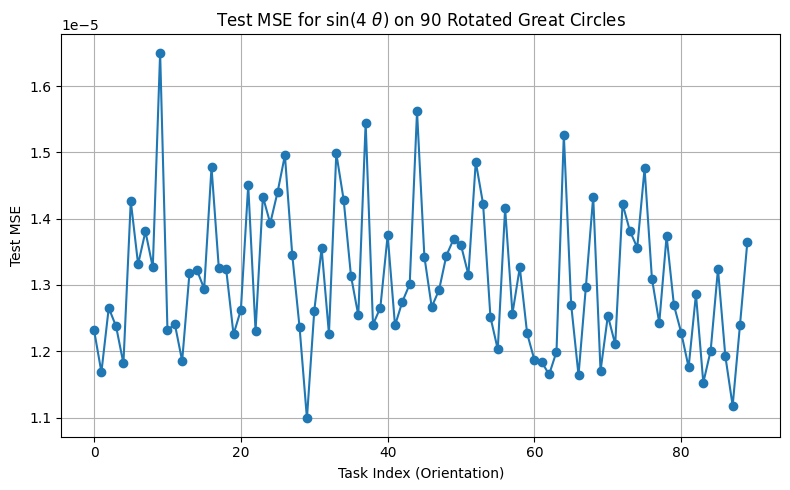

In [22]:
mse_vals = [r["mse"] for r in results_single]

plt.figure(figsize=(8,5))
plt.plot(range(num_tasks), mse_vals, marker='o')
plt.title(fr"Test MSE for sin(4 $\theta$) on {len(results_single)} Rotated Great Circles")
plt.xlabel("Task Index (Orientation)")
plt.ylabel("Test MSE")
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
configs = []
results_multi = []
m = 3

for K in [1,2,3,4,5,10,15,20,25,30,35,40,45,50,55,60,65,70,65,70,75,80,85,90]:
    configs.append(dict(K_tasks=K, pts_per_circle=256, m=m, reg_scale=1e-5))

for cfg in tqdm(configs):
    results_multi.append(run_ntk_multi_great_circle(**cfg))

100%|██████████| 24/24 [02:00<00:00,  5.04s/it]


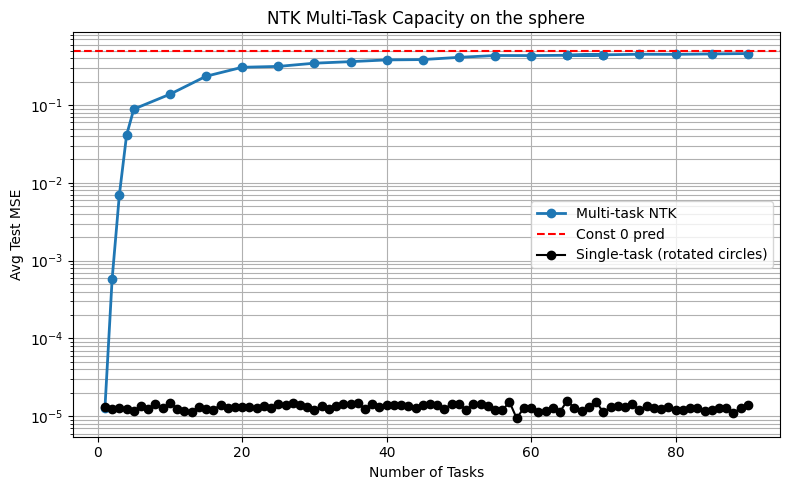

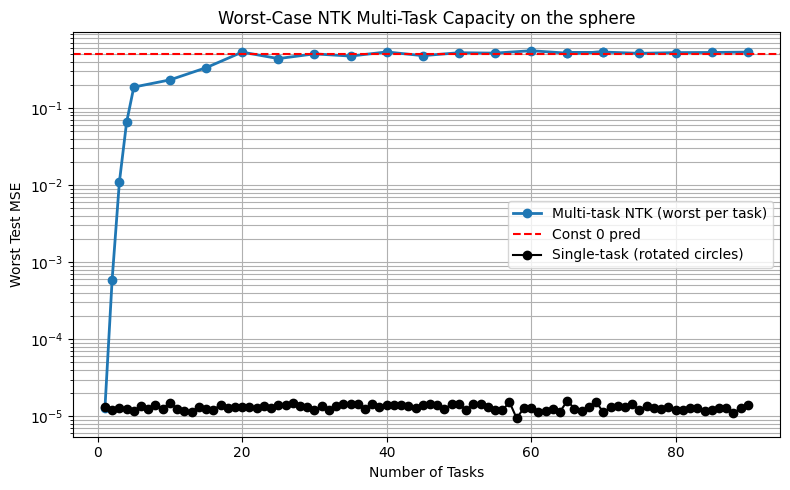

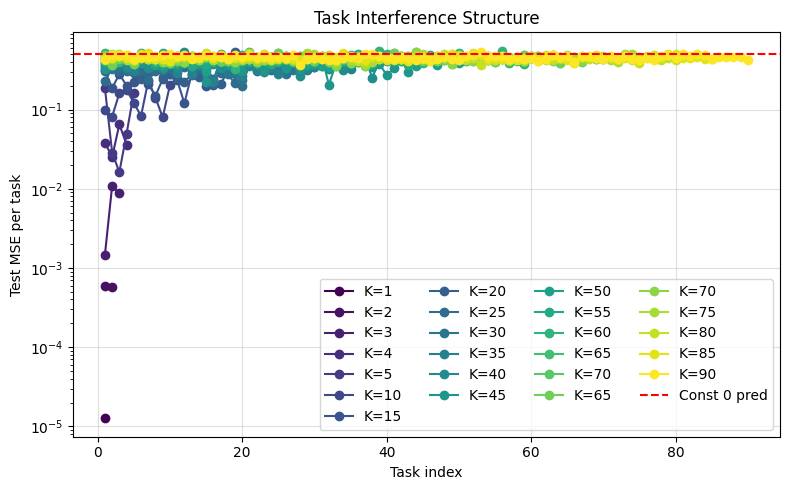

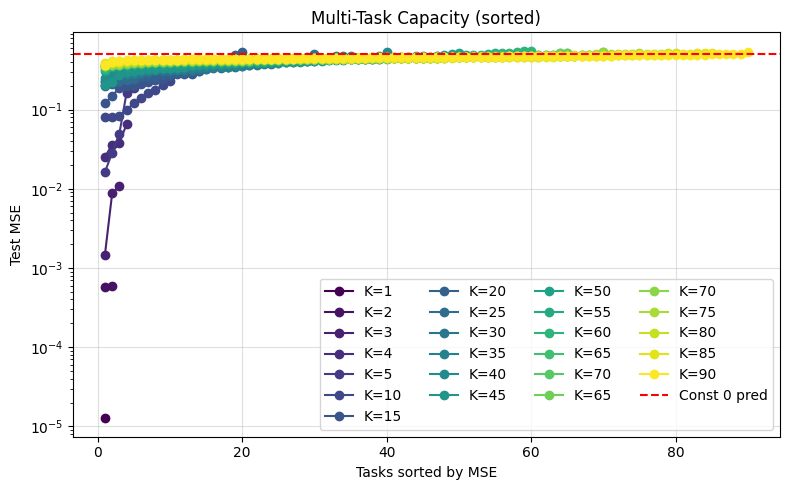

In [16]:
plot_multi_circle_avg_performance(results_multi,
                                  single_task_results=results_single)
plot_multi_circle_worst_performance(results_multi,
                                    single_task_results=results_single)
plot_per_task_mse(results_multi)
plot_sorted_task_mse(results_multi)

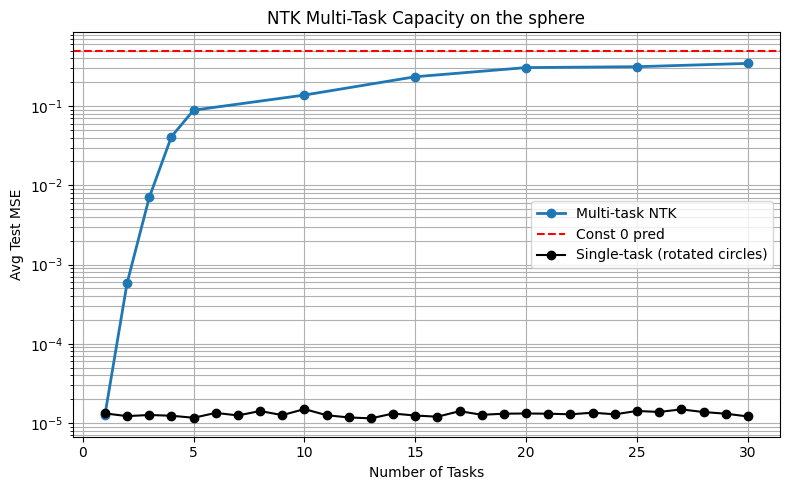

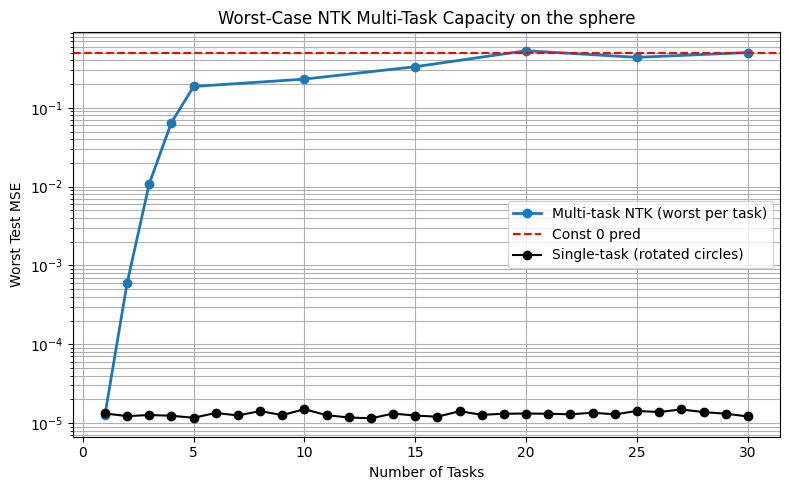

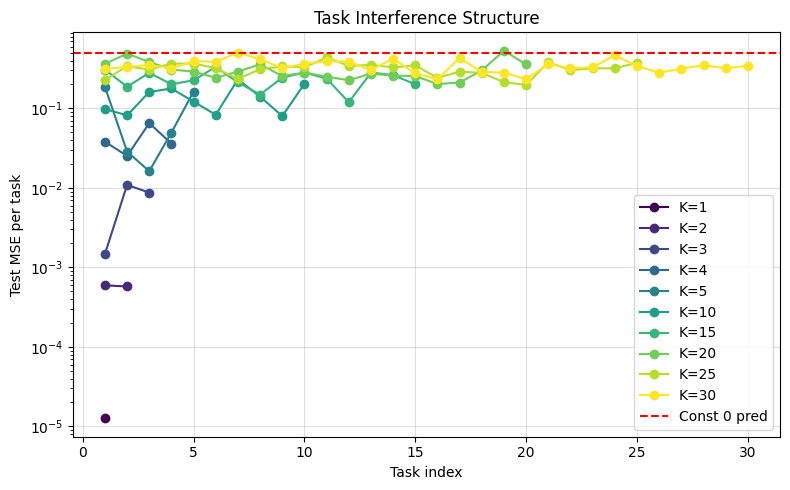

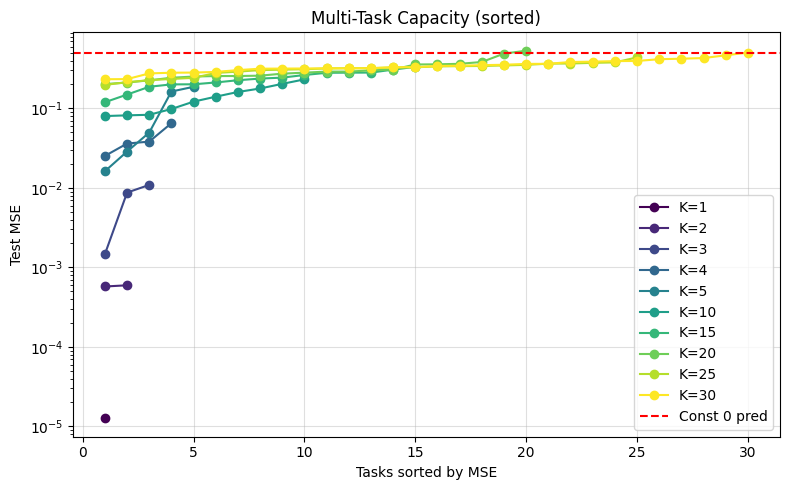

In [17]:
plot_multi_circle_avg_performance(results_multi[:10],
                                  single_task_results=results_single[:30])
plot_multi_circle_worst_performance(results_multi[:10],
                                    single_task_results=results_single[:30])
plot_per_task_mse(results_multi[:10])
plot_sorted_task_mse(results_multi[:10])

Let's see how does the bias only ntk perform.

In [23]:
num_tasks = 90
m = 3
pts_per_circle = 512
reg_scale = 1e-5

# Uniform, unique normals
normals = generate_normals(num_tasks)

configs = []
for j in range(num_tasks):
    configs.append(dict(
        normal=normals[j],
        pts_per_circle=pts_per_circle,
        m=m,
        reg_scale=reg_scale,
        trainable=("b",)
    ))

results_single = []
for cfg in tqdm(configs, desc="Running single-task sin(4 phi) NTK regressions"):
    results_single.append(run_single_circle_ntk_task(**cfg))

Running single-task sin(4 phi) NTK regressions: 100%|██████████| 90/90 [00:18<00:00,  4.83it/s]


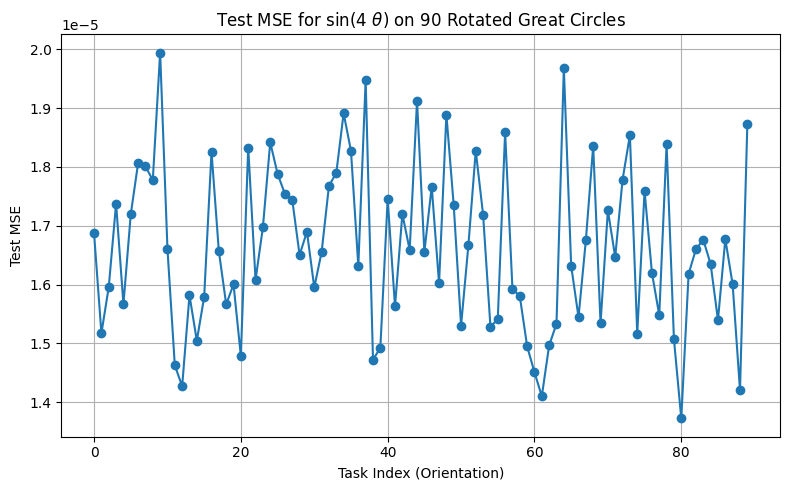

In [24]:
mse_vals = [r["mse"] for r in results_single]

plt.figure(figsize=(8,5))
plt.plot(range(num_tasks), mse_vals, marker='o')
plt.title(fr"Test MSE for sin(4 $\theta$) on {len(results_single)} Rotated Great Circles")
plt.xlabel("Task Index (Orientation)")
plt.ylabel("Test MSE")
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
configs = []
results_multi = []
m = 3

for K in [1,2,3,4,5,10,15,20,25,30,35,40,45,50,55,60,65,70,65,70,75,80,85,90]:
    configs.append(dict(K_tasks=K, pts_per_circle=256, m=m, reg_scale=1e-5, trainable=("b",)))

for cfg in tqdm(configs):
    results_multi.append(run_ntk_multi_great_circle(**cfg))

100%|██████████| 24/24 [02:02<00:00,  5.10s/it]


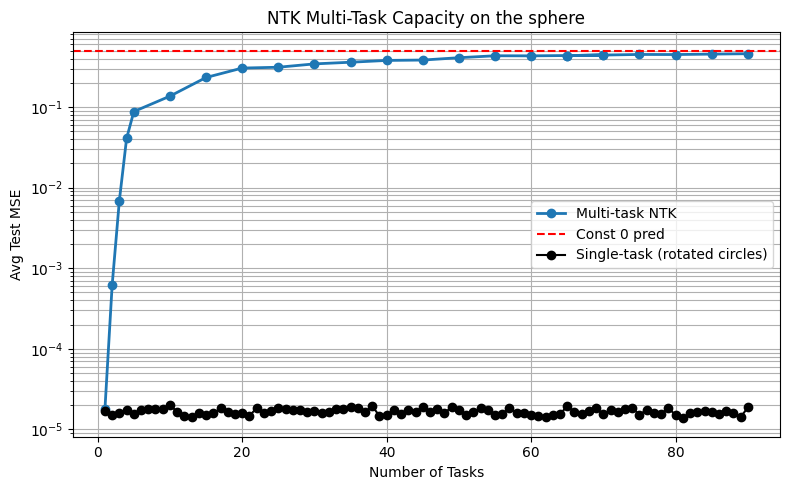

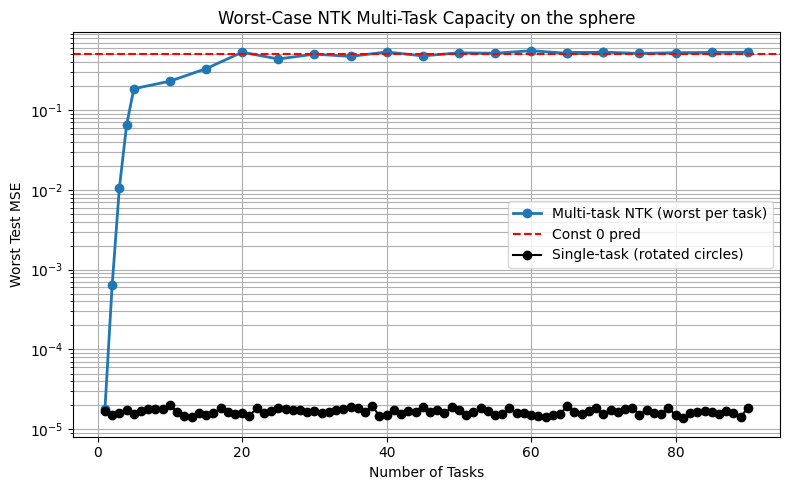

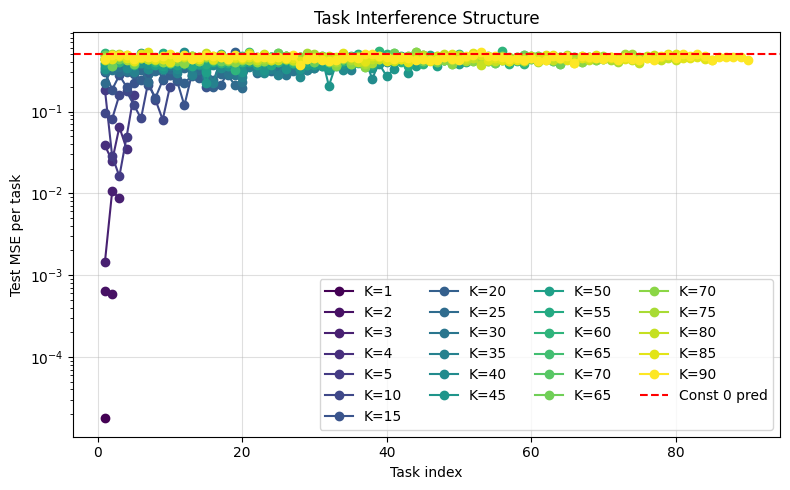

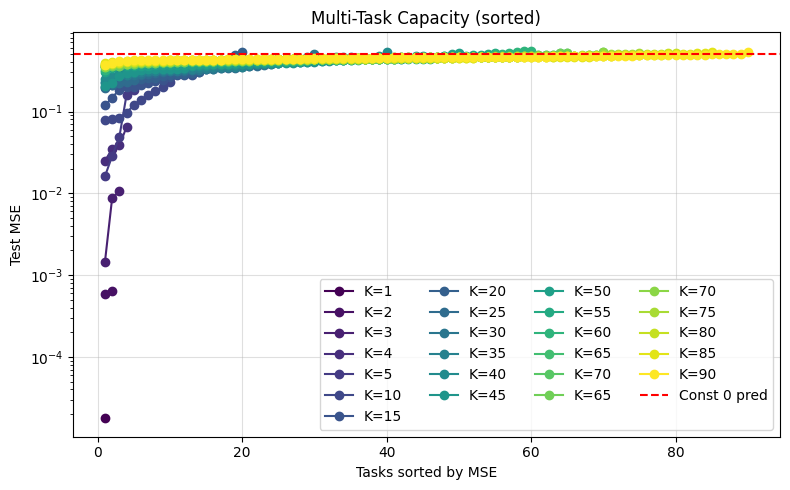

In [26]:
plot_multi_circle_avg_performance(results_multi,
                                  single_task_results=results_single)
plot_multi_circle_worst_performance(results_multi,
                                    single_task_results=results_single)
plot_per_task_mse(results_multi)
plot_sorted_task_mse(results_multi)

What happens if we increase the number of hidden layers?

In [27]:
num_tasks = 90
m = 3
pts_per_circle = 512
reg_scale = 1e-5

normals = generate_normals(num_tasks)

configs = []
for j in range(num_tasks):
    configs.append(dict(
        normal=normals[j],
        pts_per_circle=pts_per_circle,
        m=m,
        reg_scale=reg_scale,
        hidden_layers=3,
    ))

results_single = []
for cfg in tqdm(configs, desc="Running single-task sin(4 theta) NTK regressions"):
    results_single.append(run_single_circle_ntk_task(**cfg))

Running single-task sin(4 theta) NTK regressions: 100%|██████████| 90/90 [00:37<00:00,  2.40it/s]


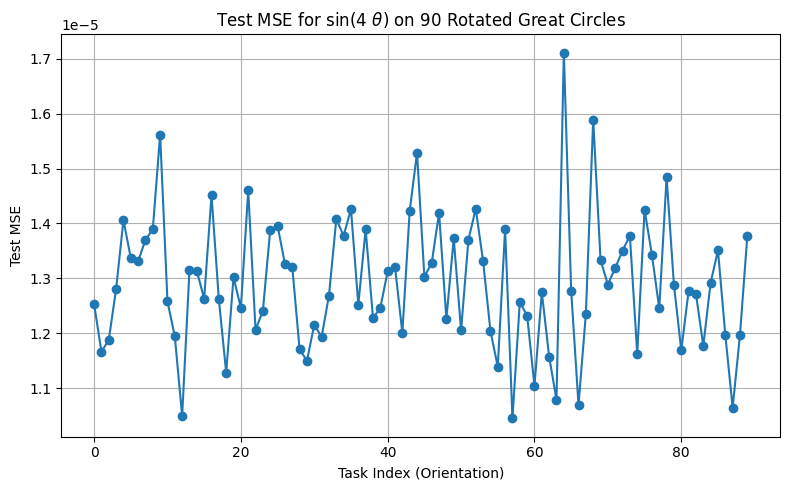

In [28]:
mse_vals = [r["mse"] for r in results_single]

plt.figure(figsize=(8,5))
plt.plot(range(num_tasks), mse_vals, marker='o')
plt.title(fr"Test MSE for sin(4 $\theta$) on {len(results_single)} Rotated Great Circles")
plt.xlabel("Task Index (Orientation)")
plt.ylabel("Test MSE")
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
configs = []
results_multi = []
m = 3

for K in [1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,45,50,55,60,65,70,65,70,75,80,85,90]:
    configs.append(dict(K_tasks=K, pts_per_circle=256, m=m, reg_scale=1e-5, hidden_layers=3))

for cfg in tqdm(configs):
    results_multi.append(run_ntk_multi_great_circle(**cfg))

100%|██████████| 28/28 [02:15<00:00,  4.85s/it]


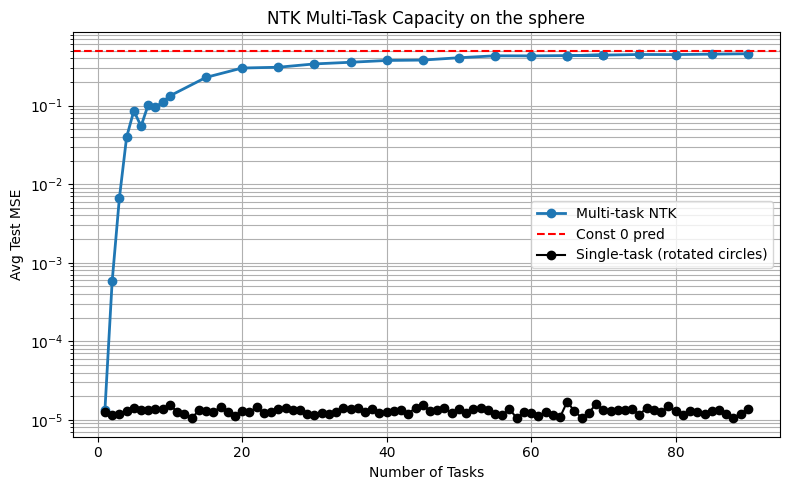

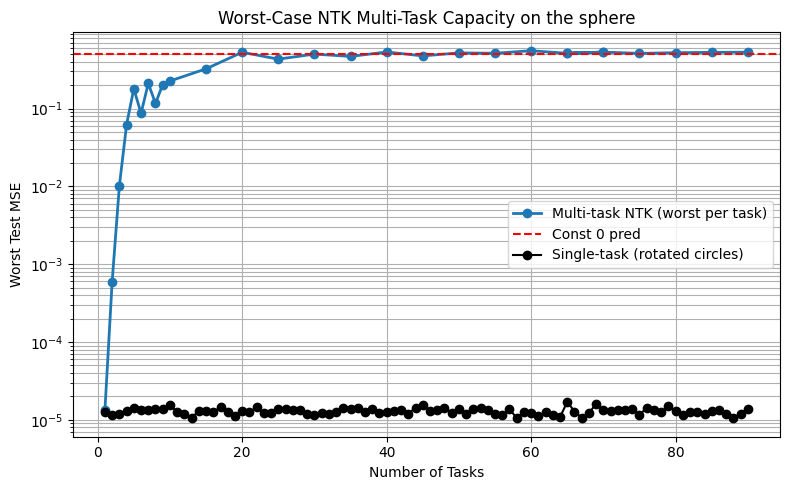

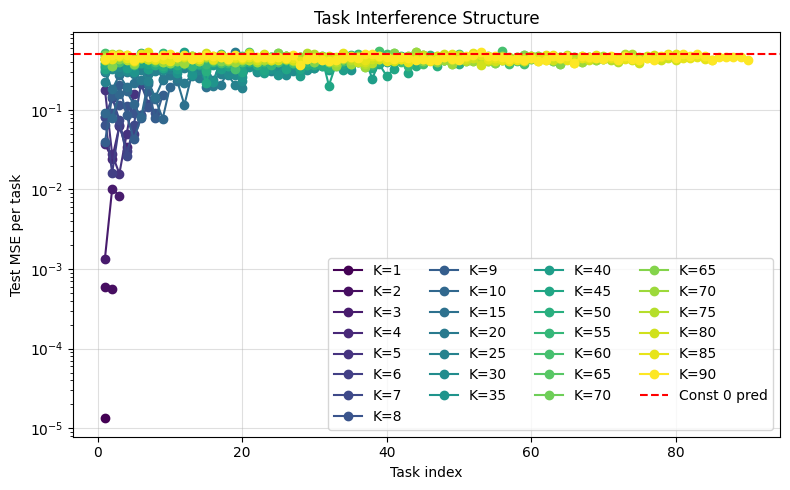

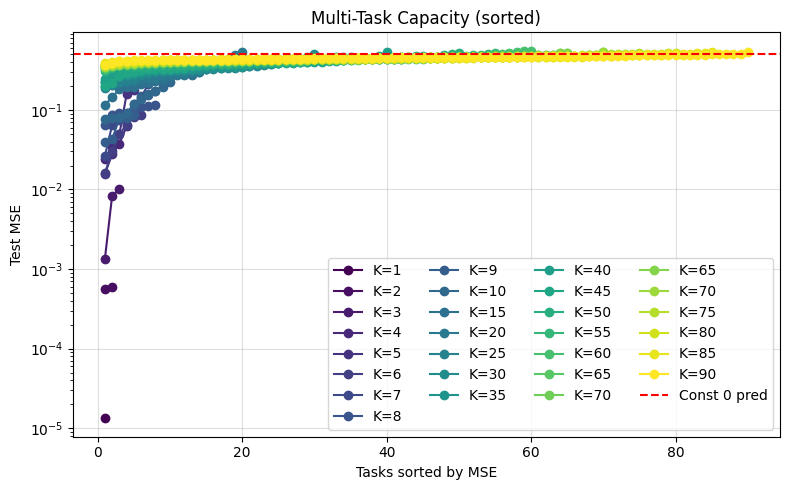

In [30]:
plot_multi_circle_avg_performance(results_multi,
                                  single_task_results=results_single)
plot_multi_circle_worst_performance(results_multi,
                                    single_task_results=results_single)
plot_per_task_mse(results_multi)
plot_sorted_task_mse(results_multi)

In infinite width, hidden_layers doesn't affect much. Now we want to explain why the performance decreases as we increase K. Our hypothesis comes from the spectral analysis of the ntk on the sphere, which tells us that the higher degree spherical harmonics have an associated eigenvalue which is vanishingly small as you increase l. Our hypothesis is that, when we increase K, the decomposition of all the points we want to fit onto the spherical harmonics places higher and higher coefficients on the high degree spherical harmonics since the fit becomes more complicated. Because of the exponential decrease of the magnitude of the eigenvalues this makes it so that the ntk is not able to learn the tasks because the needed harmonics are underrepresented in the RHKS.

What we do is, for a specific K, take the harmonics up to a degree $L_{max}$ and solve the optimization problem $argmin_{c} \; y_{true} - \sum_{l<L_{max}, -l\leq m\leq +l} c_{l,m}Y_{l,m}\quad$. This gives us the best approximation of the dataset we can get by using harmonics of degree $L_{max}$ and lower. We can see how the theoretical performance evolves as we allow for the use of more complex harmonics and see how the ntk performance compares.

In [31]:
def compute_sh_design_matrix(theta, phi, L_max):
    Phi_cols = []
    lm_pairs = []
    for l in range(L_max+1):
        for m in range(-l, l+1):
            lm_pairs.append((l, m))
            Phi_cols.append(sph_harm(m, l, phi, theta))
    Phi = np.column_stack(Phi_cols)
    return Phi, lm_pairs


def best_fit_vs_degree(res, L_max=20, lam=1e-8, use_pred=False):
    """
    Returns:
      mse_curve[L0] = best MSE using all basis thru degree L0
      coeffs_by_L[L0] = coefficient vector fit with max degree L0
      lm_pairs = order of harmonics
      (theta, phi, y_true) = spherical coords + labels for recon
    """

    X_concat = np.vstack([task["X"] for task in res["tasks"]])
    y_true = np.hstack([task["y_pred" if use_pred else "y_true"]
                        for task in res["tasks"]])

    x, ycoord, z = X_concat[:,0], X_concat[:,1], X_concat[:,2]
    z = np.clip(z, -1.0, 1.0)
    theta = np.arccos(z)
    phi = np.arctan2(ycoord, x) % (2*np.pi)

    Phi_full, lm_pairs = compute_sh_design_matrix(theta, phi, L_max)

    mse_curve = []
    coeffs_by_L = []
    basis_sizes = np.cumsum([2*l+1 for l in range(L_max+1)])

    for L0 in range(L_max+1):
        n_basis = basis_sizes[L0]
        Phi = Phi_full[:, :n_basis]

        A = Phi.conj().T @ Phi + lam*np.eye(n_basis)
        b = Phi.conj().T @ y_true
        c = np.linalg.solve(A, b)

        y_hat = np.real(Phi @ c)
        mse_curve.append(np.mean((y_true - y_hat)**2))
        coeffs_by_L.append(c)

    return np.array(mse_curve), coeffs_by_L, lm_pairs, (theta, phi, y_true)

def cumulative_recon_mse(coeffs_by_L, lm_pairs, theta, phi, y_true):
    L_max = len(coeffs_by_L) - 1
    mse_mat = np.zeros((L_max+1, L_max+1))

    # Precompute all harmonics
    Y_all = { (l,m): sph_harm(m, l, phi, theta)
              for (l,m) in lm_pairs }

    basis_sizes = np.cumsum([2*l+1 for l in range(L_max+1)])

    for L0, c in enumerate(coeffs_by_L):
        for l_cut in range(L0+1):
            n_basis = basis_sizes[l_cut]
            c_sub = c[:n_basis]

            y_recon = np.zeros_like(y_true, dtype=complex)
            idx = 0
            for l in range(l_cut+1):
                for m in range(-l,l+1):
                    y_recon += c_sub[idx] * Y_all[(l,m)]
                    idx += 1

            mse_mat[L0, l_cut] = np.mean((y_true - y_recon.real)**2)

        mse_mat[L0, L0+1:] = np.nan  # unused upper triangle

    return mse_mat

def analyze_spectral_data(results_multi, L_max=50, use_pred=False):
    """
    Computes:
        - SH MSE curves
        - NTK regression MSEs
        - l* learnability cutoffs using 'closest match' heuristic
    """

    Ks, mse_curves, ntk_mses, L_stars = [], [], [], []

    for res in tqdm(results_multi):
        K = res["K_tasks"]
        Ks.append(K)

        # NTK regression MSE
        ntk_mse = float(np.max(res["mse_per_task"]))
        ntk_mses.append(ntk_mse)

        # SH representation MSE curve
        mse_curve, coeffs_by_L, lm_pairs, (theta, phi, y_true) = \
            best_fit_vs_degree(res, L_max=L_max, use_pred=use_pred)

        mse_curves.append(mse_curve)

        # ℓ* = degree whose SH MSE is closest to NTK MSE
        diffs = np.abs(mse_curve - ntk_mse)
        L_star = int(np.argmin(diffs))
        L_stars.append(L_star)

    return Ks, mse_curves, ntk_mses, L_stars

In [32]:
def plot_cumulative_recon_curves(mse_mat, K, ntk_mse):
    L_max = mse_mat.shape[0] - 1
    cmap = plt.get_cmap("viridis")

    plt.figure(figsize=(12, 7))

    # Plot curves for each ℓ_max
    for L0 in range(L_max+1):
        color = cmap(L0 / L_max)
        plt.plot(range(L0+1), mse_mat[L0, :L0+1],
                 marker="o", lw=2, alpha=0.85, color=color,
                 label=fr"$L_{{\mathrm{{max}}}} = {L0}$")


    # --- Horizontal NTK performance cutoff ---
    """
    plt.axhline(y=ntk_mse,
                color="black", linestyle="--",
                linewidth=2, alpha=0.9,
                label=f"NTK MSE")
    """
                
    plt.yscale("log")
    plt.xlabel(r"Cumulative included degree $\ell$")
    plt.ylabel("Reconstruction MSE")
    plt.title(fr"Cumulative SH Reconstruction vs $\ell$ (K={K})")
    plt.grid(True, alpha=0.35)
    plt.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    plt.show()

def plot_spectral_results(Ks, mse_curves, ntk_mses, L_stars, L_max=50):

    # Sort entries by increasing K
    order = np.argsort(Ks)
    Ks = np.array(Ks)[order]
    mse_curves = [mse_curves[i] for i in order]
    ntk_mses = np.array(ntk_mses)[order]
    L_stars = np.array(L_stars)[order]

    plt.figure(figsize=(15, 8))

    # Updated non-deprecated colormap usage
    cmap = plt.colormaps["viridis"]
    N = len(Ks)

    for i, (K, curve, ntk_mse, L_star) in enumerate(zip(Ks, mse_curves, ntk_mses, L_stars)):
        color = cmap(i / max(1, N - 1))

        # SH curve
        plt.plot(
            np.arange(len(curve)),
            curve,
            marker="o",
            lw=2,
            color=color,
            alpha=1,
            label=f"K={K}"
        )

        # Horizontal NTK performance level
        plt.hlines(
            ntk_mse,
            xmin=0,
            xmax=len(curve) - 1,
            linestyle="--",
            color=color,
            alpha=1
        )

        # Vertical ℓ* cutoff
        if L_star is not None:
            plt.vlines(
                L_star,
                ymin=np.min(curve),
                ymax=np.max(curve),
                linestyle=":",
                color=color,
                alpha=1
            )

    plt.yscale("log")
    plt.xlabel(r"Spherical Harmonic Degree $L_{max}$", fontsize=12)
    plt.ylabel("Best SH Fit MSE", fontsize=12)
    plt.title("SH Representation vs NTK Performance\nwith Learnability Cutoffs", fontsize=15)
    plt.grid(True, which="both", alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()


In [33]:
Ks, mse_curves, ntk_mses, L_stars = analyze_spectral_data(results_multi[:10], L_max=50)

100%|██████████| 10/10 [02:04<00:00, 12.46s/it]


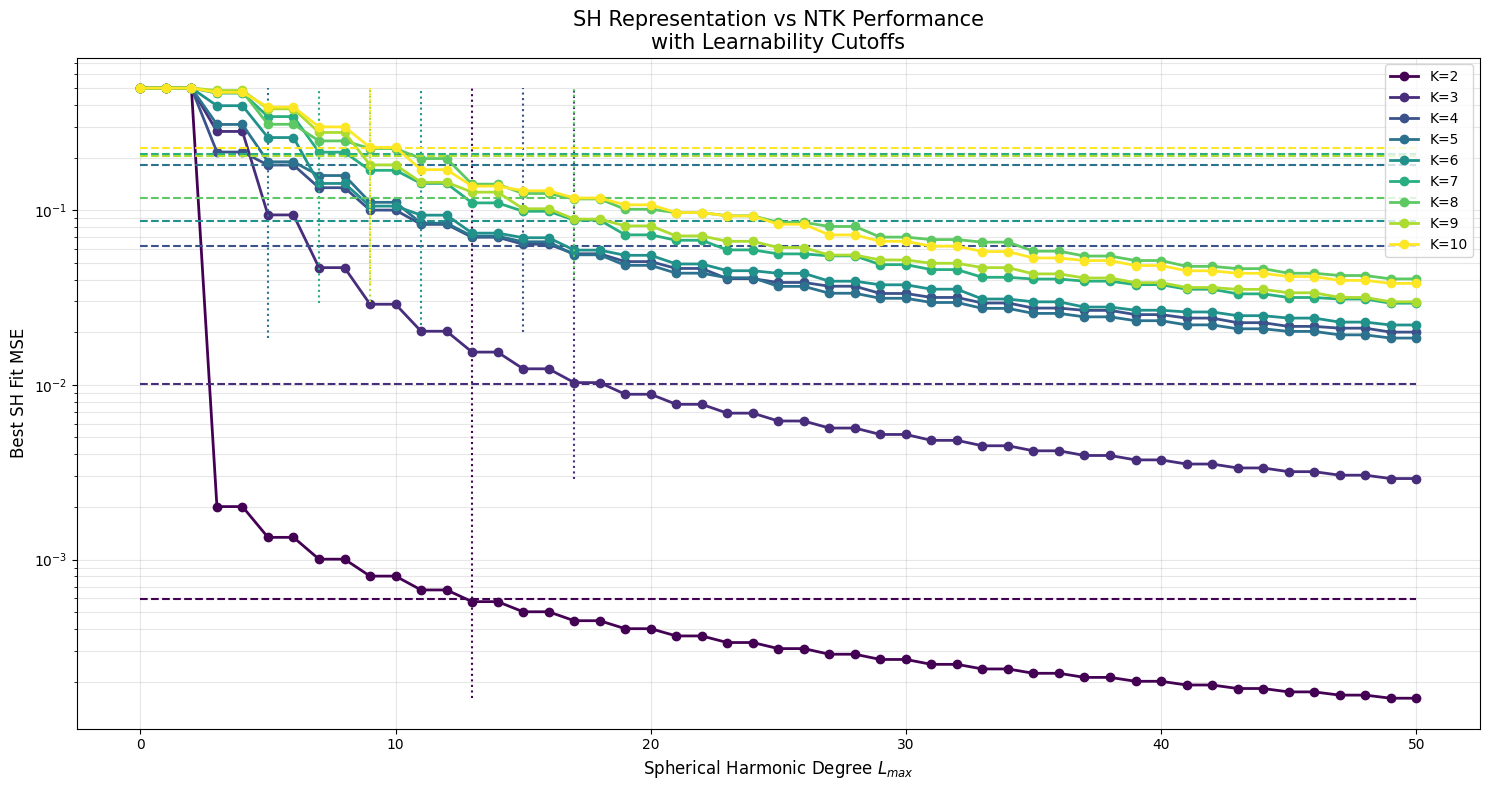

In [34]:
indexes = np.arange(1,10)

Ks = np.array(Ks)
mse_curves = np.array(mse_curves, dtype=object)  # important: dtype=object for ragged arrays
ntk_mses = np.array(ntk_mses)
L_stars = np.array(L_stars)

plot_spectral_results(
    Ks[indexes],
    mse_curves[indexes].tolist(),  # convert back to list for plotting
    ntk_mses[indexes],
    L_stars[indexes],
    L_max=50
)

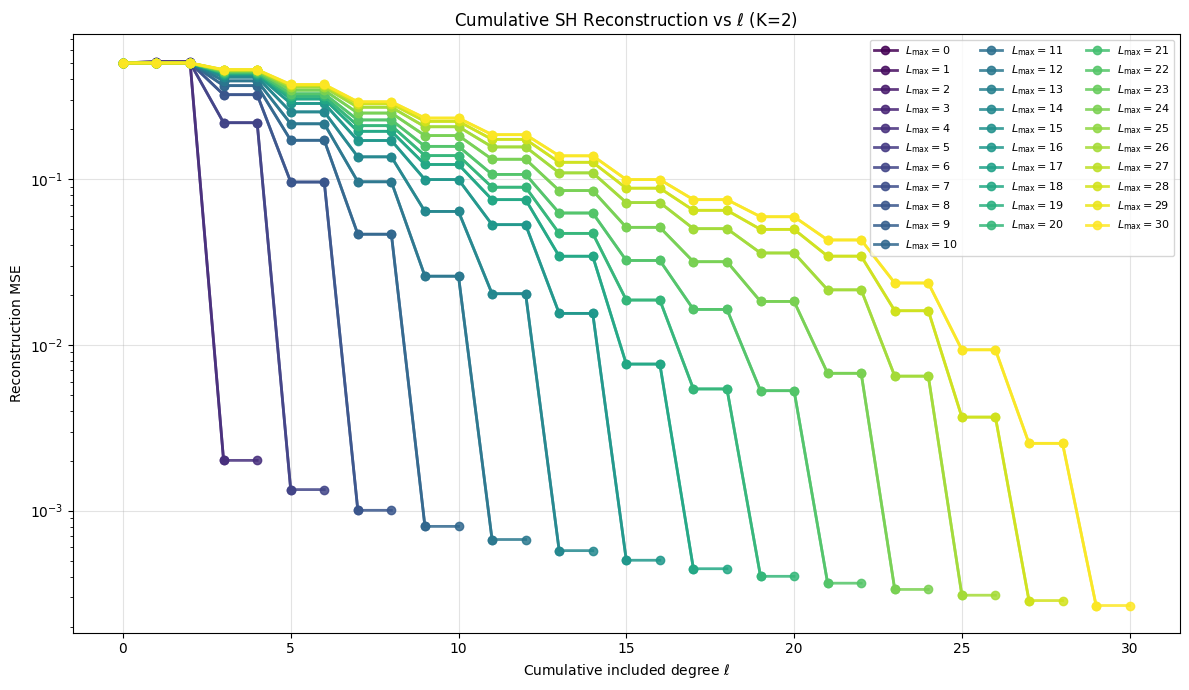

In [39]:
res = results_multi[1] # pick whichever K
K = res["K_tasks"]
ntk_mse = np.max(res["mse_per_task"])  # worst-task test MSE

mse_curve, coeffs_by_L, lm_pairs, (theta, phi, y_true) = \
    best_fit_vs_degree(res, L_max=30)

mse_mat = cumulative_recon_mse(coeffs_by_L, lm_pairs, theta, phi, y_true)

plot_cumulative_recon_curves(mse_mat, K, ntk_mse)


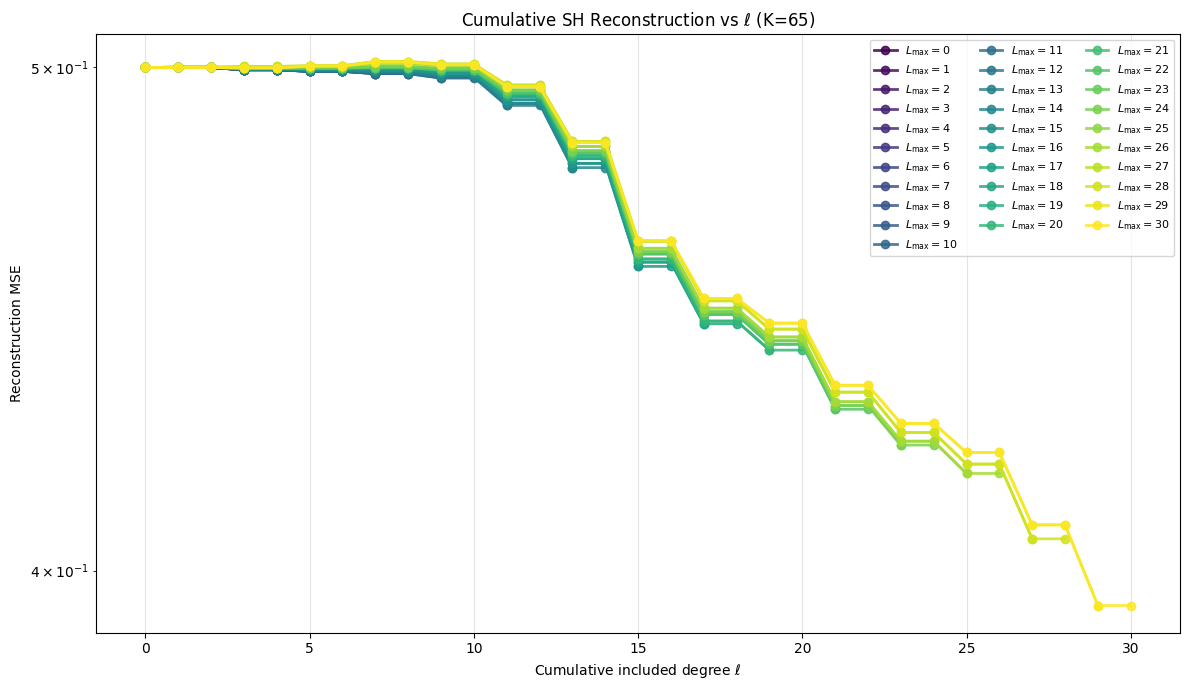

In [37]:
res = results_multi[20] # pick whichever K
K = res["K_tasks"]
ntk_mse = np.max(res["mse_per_task"])  # worst-task test MSE

mse_curve, coeffs_by_L, lm_pairs, (theta, phi, y_true) = \
    best_fit_vs_degree(res, L_max=30)

mse_mat = cumulative_recon_mse(coeffs_by_L, lm_pairs, theta, phi, y_true)

plot_cumulative_recon_curves(mse_mat, K, ntk_mse)

/tmp/ipykernel_1437949/3895071915.py:35: ComplexWarning: Casting complex values to real discards the imaginary part
  coeff_mat[L, :len(coeffs)] = coeffs
/tmp/ipykernel_1437949/3895071915.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


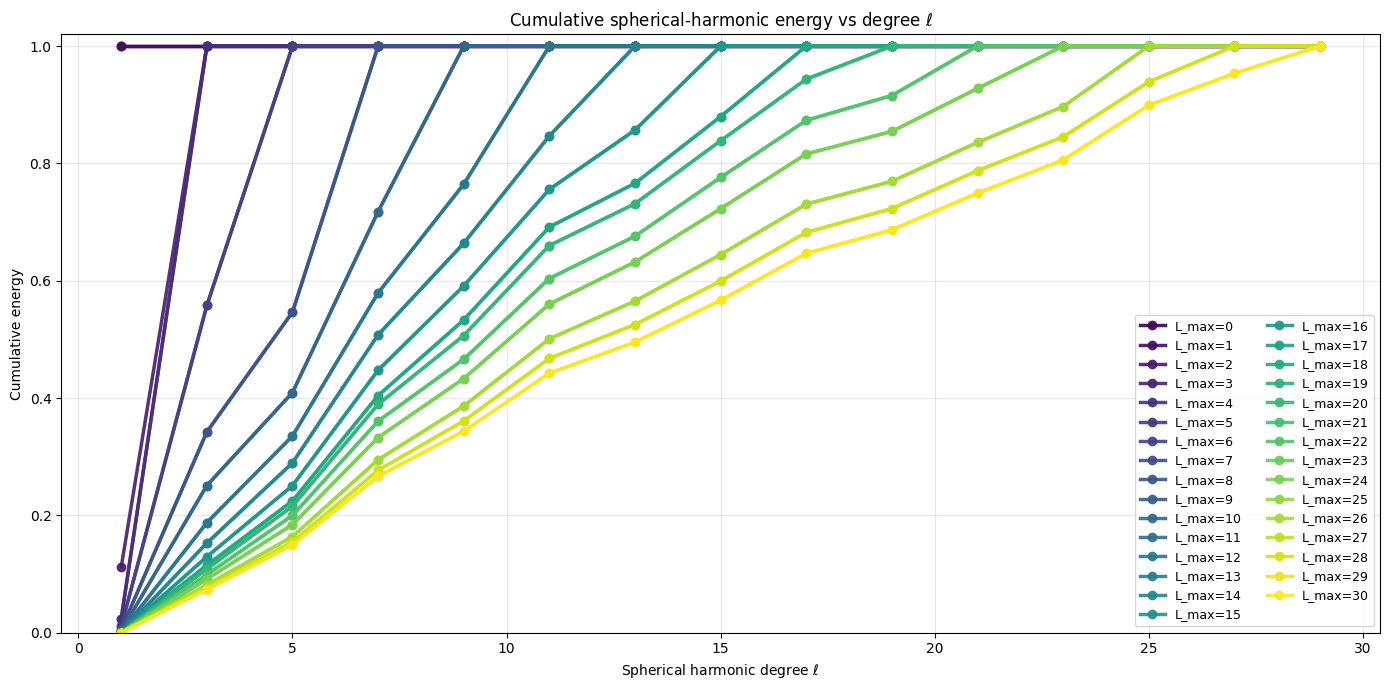

/tmp/ipykernel_1437949/3895071915.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


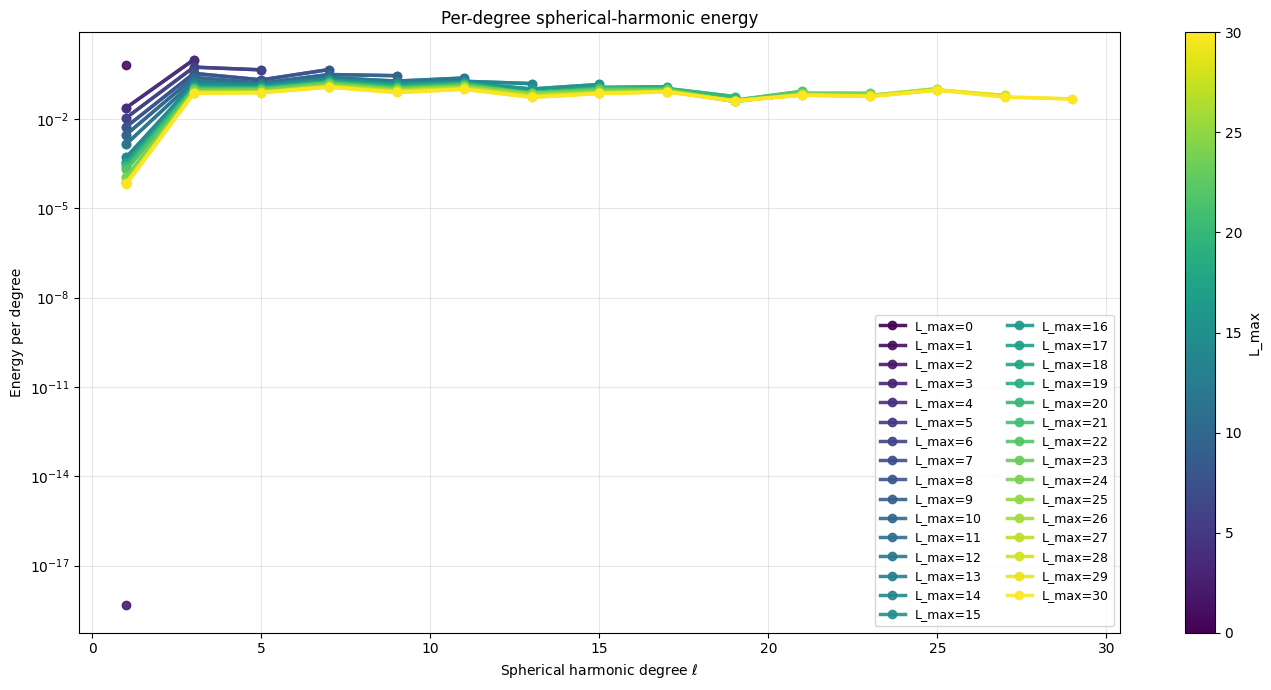

In [41]:
# Take the K=2 case

res = results_multi[1] # pick whichever K
K = res["K_tasks"]
ntk_mse = np.max(res["mse_per_task"])  # worst-task test MSE

mse_curve, coeffs_by_L, lm_pairs, (theta, phi, y_true) = \
    best_fit_vs_degree(res, L_max=30)

mse_mat = cumulative_recon_mse(coeffs_by_L, lm_pairs, theta, phi, y_true)

L_final = len(coeffs_by_L) - 1
N_coeffs = (L_final + 1) ** 2

# Unravel index l
def ell_from_index(idx):
    ell = 0
    count = 0
    while count + (2 * ell + 1) <= idx:
        count += 2 * ell + 1
        ell += 1
    return ell

# get l index for each unravelled coefficient
ell_idx = np.array([ell_from_index(i) for i in range(N_coeffs)])

# Build a coefficient matrix
#   rows = L_max
#   cols = unravelled (l,m)

coeff_mat = np.full((L_final + 1, N_coeffs), np.nan)

for L, coeff_list in enumerate(coeffs_by_L):
    coeffs = np.asarray(coeff_list)
    coeff_mat[L, :len(coeffs)] = coeffs

# Compute energy per l
#   E_l = sum_m |c_{lm}|^2
ell_max = L_final
energy_mat = np.full((L_final + 1, ell_max + 1), np.nan)

for L in range(L_final + 1):
    coeffs = coeff_mat[L]
    for ell in range(ell_max + 1):
        mask = ell_idx == ell
        vals = coeffs[mask]
        vals = vals[~np.isnan(vals)]
        if len(vals) > 0:
            energy_mat[L, ell] = np.sum(np.abs(vals) ** 2)

# Normalize energy (recommended)
energy_mat /= np.nansum(energy_mat, axis=1, keepdims=True)

# Cumulative energy vs ℓ
cum_energy = np.nancumsum(energy_mat, axis=1)

# Plot (ODD l ONLY)
fig, ax = plt.subplots(figsize=(14, 7))
cmap = cm.get_cmap("viridis")

ells = np.arange(ell_max + 1)
odd_mask = (ells % 2 == 1)

for L in range(L_final + 1):
    color = cmap(L / L_final)
    ax.plot(
        ells[odd_mask],
        cum_energy[L, odd_mask],
        lw=2.5,
        alpha=0.9,
        color=color,
        marker="o",
        label=f"L_max={L}"
    )

ax.set_xlabel(r"Spherical harmonic degree $\ell$")
ax.set_ylabel(r"Cumulative energy")
ax.set_title(r"Cumulative spherical-harmonic energy vs degree $\ell$")
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.02)

ax.legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

# Plot PER-l energy (ODD l ONLY)
fig, ax = plt.subplots(figsize=(14, 7))
cmap = cm.get_cmap("viridis")

ells = np.arange(ell_max + 1)
odd_mask = (ells % 2 == 1)

for L in range(L_final + 1):
    color = cmap(L / L_final)
    ax.plot(
        ells[odd_mask],
        energy_mat[L, odd_mask],
        lw=2.5,
        alpha=0.9,
        color=color,
        marker="o",
        label=f"L_max={L}"
    )

ax.set_xlabel(r"Spherical harmonic degree $\ell$")
ax.set_ylabel(r"Energy per degree")
ax.set_title("Per-degree spherical-harmonic energy")
ax.grid(True, alpha=0.3)
ax.set_yscale("log")
ax.legend(ncol=2, fontsize=9)

# Colorbar for L progression
sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=plt.Normalize(vmin=0, vmax=L_final)
)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="L_max")

plt.tight_layout()
plt.show()

/tmp/ipykernel_1437949/2211064348.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


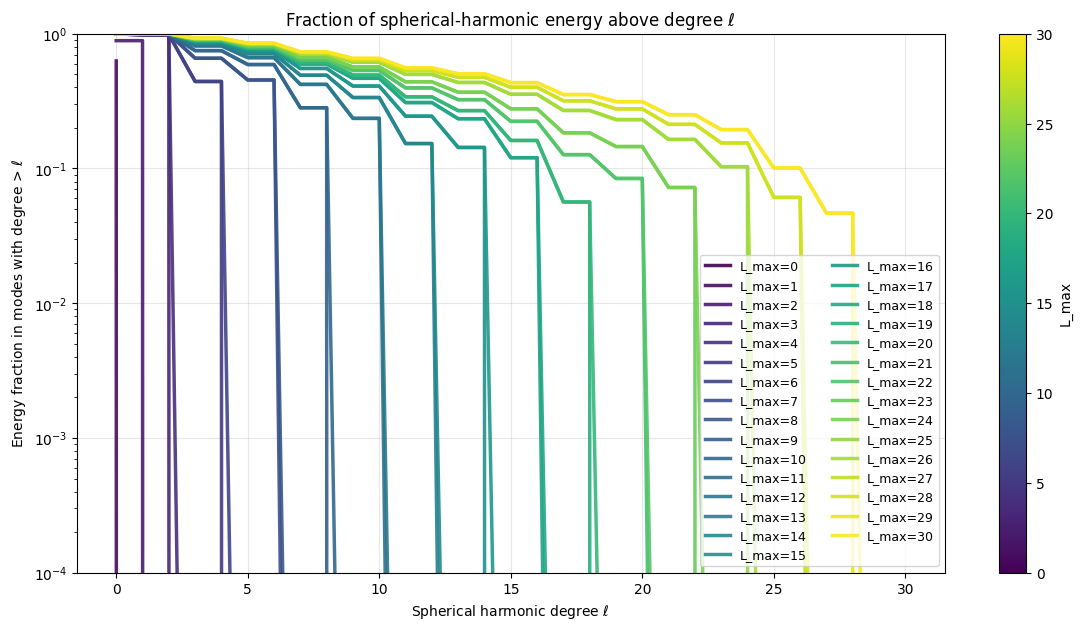

In [45]:
# Compute the energy fraction above degree l
energy_above = 1.0 - cum_energy

fig, ax = plt.subplots(figsize=(14, 7))
cmap = cm.get_cmap("viridis")

ells = np.arange(ell_max + 1)

for L in range(L_final + 1):
    color = cmap(L / L_final)
    ax.plot(
        ells,
        energy_above[L],
        lw=2.5,
        alpha=0.9,
        color=color,
        label=f"L_max={L}"
    )

ax.set_xlabel(r"Spherical harmonic degree $\ell$")
ax.set_ylabel(r"Energy fraction in modes with degree > $\ell$")
ax.set_title(r"Fraction of spherical-harmonic energy above degree $\ell$")
ax.grid(True, alpha=0.3)
ax.set_yscale("log")
ax.set_ylim(1e-4, 1.0)

ax.legend(ncol=2, fontsize=9)

# Colorbar for L progression
sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=plt.Normalize(vmin=0, vmax=L_final)
)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="L_max")

In [64]:
width=None
hidden_layers=1
W_std=1
b_std=1
trainable=("W","b")
K_tasks=2

X_train_np, y_train_np, task_slices_train, normals_train = generate_multi_great_circle_tasks(
        K_tasks=K_tasks,
        pts_per_circle=pts_per_circle,
        m=m,
    )

# Use random phase because otherwise the test includes the training
X_test_np, y_test_np, task_slices_test, normals_test = generate_multi_great_circle_tasks(
    K_tasks=K_tasks,
    pts_per_circle=2 * pts_per_circle,
    m=m,
    random_phase=True
)

X_train = jnp.array(X_train_np, dtype=jnp.float32)
y_train = jnp.array(y_train_np, dtype=jnp.float32)
X_test  = jnp.array(X_test_np,  dtype=jnp.float32)
y_test  = jnp.array(y_test_np,  dtype=jnp.float32)

N_train = X_train.shape[0]

if width is None:

    # Do Infinite-width analytic NTK
    layers = []
    for _ in range(hidden_layers):
        # Width does not matter in the analytic NTK because neural tangents ignores it anyways
        layers.append(
            stax.Dense(
                1,
                W_std=W_std,
                b_std=b_std,
                parameterization="ntk",
                trainable=trainable,
            )
        )
        layers.append(stax.Relu())

    # Final scalar output layer
    layers.append(
        stax.Dense(
            1,
            W_std=W_std,
            b_std=b_std,
            parameterization="ntk",
            trainable=trainable,
        )
    )

    _, _, kernel_fn = stax.serial(*layers)
    kernel_fn = nt.batch(kernel_fn, device_count=-1)

    # Get kernels
    K_train = jnp.array(kernel_fn(X_train, X_train, "ntk"))
    K_test_train = jnp.array(kernel_fn(X_test, X_train, "ntk"))

# Do spectral analysis
eigvals = jnp.linalg.eigvalsh(K_train)

# Regression
reg = float(jnp.max(eigvals)) * reg_scale
K_reg = K_train + reg * jnp.eye(N_train)
y_train_col = y_train.reshape(-1, 1)
alpha = jnp.linalg.solve(K_reg, y_train_col)

# Predict on test set and flatten
y_pred_test = (K_test_train @ alpha).reshape(-1)

# Save data
task_results = []
mse_test_per_task = []

for sl in task_slices_test:
    yt = np.array(y_test_np[sl])
    yp = np.array(y_pred_test[sl])
    mse = float(np.mean((yt - yp) ** 2))

    Xt = np.array(X_test_np[sl])
    task_results.append(
        dict(
            y_true=yt,
            y_pred=yp,
            X=Xt,
        )
    )
    mse_test_per_task.append(mse)
